# 📊 Notebook 1: Exploratory Data Analysis (EDA) & Preprocessing
## Lokalisasi Sumber PVC/VT menggunakan 12-Lead ECG

**Tujuan Notebook ini:**
1. Memuat dan memahami dataset diagnosis pasien
2. Memuat dan memvisualisasikan sinyal EKG 12-Lead
3. Mencocokkan data pasien dengan rekaman EKG
4. Analisis distribusi label (lokalisasi sumber PVC)
5. Deteksi missing data
6. Discrete Wavelet Transform (DWT) untuk denoising sinyal EKG
7. Splitting data 80/20 (stratified)
8. Menyimpan data yang telah diproses

---

## 1. Import Library & Konfigurasi

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats, signal
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi plot
plt.rcParams.update({
    'figure.figsize': (16, 8),
    'figure.dpi': 100,
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 0.8,
})

# Color palette
COLORS = {
    'primary': '#2563EB',
    'secondary': '#7C3AED',
    'success': '#059669',
    'danger': '#DC2626',
    'warning': '#D97706',
    'info': '#0891B2',
    'dark': '#1F2937',
    'light': '#F3F4F6',
}

# 12-Lead ECG standard colors
LEAD_COLORS = {
    'I': '#E63946', 'II': '#457B9D', 'III': '#2A9D8F',
    'aVR': '#E76F51', 'aVL': '#F4A261', 'aVF': '#264653',
    'V1': '#6A0572', 'V2': '#AB83A1', 'V3': '#F15BB5',
    'V4': '#00BBF9', 'V5': '#00F5D4', 'V6': '#FEE440',
}

# Path konfigurasi
BASE_DIR = Path('.')
RAW_ECG_DIR = BASE_DIR / 'PVCVTRawECGData'
PROCESSED_ECG_DIR = BASE_DIR / 'PVCVTECGData'
DIAGNOSIS_FILE = BASE_DIR / 'Diagnosis.xlsx'
OUTPUT_DIR = BASE_DIR / 'preprocessed_data'
OUTPUT_DIR.mkdir(exist_ok=True)

SAMPLING_RATE = 1000  # Asumsi 1000 Hz (standar EKG digital)

print("✅ Library berhasil dimuat!")
print(f"📁 Base Directory: {BASE_DIR.resolve()}")

✅ Library berhasil dimuat!
📁 Base Directory: /Users/daniandra/Downloads/TA GUWEH/PVC-Localization-with-CNN-Transformer


---
## 2. Memuat Data Diagnosis Pasien

In [34]:
# Memuat data diagnosis
df_diagnosis = pd.read_excel(DIAGNOSIS_FILE)

print("=" * 70)
print("📋 INFORMASI DATASET DIAGNOSIS")
print("=" * 70)
print(f"\n📐 Dimensi: {df_diagnosis.shape[0]} pasien × {df_diagnosis.shape[1]} kolom")
print(f"\n📊 Kolom: {df_diagnosis.columns.tolist()}")
print(f"\n🔢 Tipe Data:")
for col in df_diagnosis.columns:
    print(f"   • {col}: {df_diagnosis[col].dtype}")

print(f"\n📋 Preview Data (5 baris pertama):")
df_diagnosis.head()

📋 INFORMASI DATASET DIAGNOSIS

📐 Dimensi: 334 pasien × 5 kolom

📊 Kolom: ['HospitalID', 'Type', 'LeftRight', 'Sublocation', 'Gender']

🔢 Tipe Data:
   • HospitalID: int64
   • Type: object
   • LeftRight: object
   • Sublocation: object
   • Gender: object

📋 Preview Data (5 baris pertama):


,HospitalID,Type,LeftRight,Sublocation,Gender
0,702840,PVC,Right,PosteriorSeptal,female
1,707139,PVC,Right,PosteriorSeptal,male
2,708534,PVC,Right,PosteriorSeptal,female
3,707971,PVC,Right,FreeWall,female
4,740908,PVC,Right,RVOTOther,female


In [35]:
# Statistik deskriptif
print("=" * 70)
print("📊 STATISTIK DESKRIPTIF")
print("=" * 70)

for col in df_diagnosis.columns:
    n_unique = df_diagnosis[col].nunique()
    n_null = df_diagnosis[col].isnull().sum()
    print(f"\n🔹 {col}:")
    print(f"   Unique values: {n_unique}")
    print(f"   Missing values: {n_null} ({n_null/len(df_diagnosis)*100:.1f}%)")
    if n_unique <= 15:
        print(f"   Distribution:")
        for val, count in df_diagnosis[col].value_counts().items():
            pct = count / len(df_diagnosis) * 100
            bar = '█' * int(pct / 2)
            print(f"     {val:>20s}: {count:>4d} ({pct:5.1f}%) {bar}")

📊 STATISTIK DESKRIPTIF

🔹 HospitalID:
   Unique values: 334
   Missing values: 0 (0.0%)

🔹 Type:
   Unique values: 2
   Missing values: 0 (0.0%)
   Distribution:
                      PVC:  329 ( 98.5%) █████████████████████████████████████████████████
                       VT:    5 (  1.5%) 

🔹 LeftRight:
   Unique values: 2
   Missing values: 0 (0.0%)
   Distribution:
                    Right:  257 ( 76.9%) ██████████████████████████████████████
                     Left:   77 ( 23.1%) ███████████

🔹 Sublocation:
   Unique values: 12
   Missing values: 40 (12.0%)
   Distribution:
                       LC:   71 ( 21.3%) ██████████
                      LCC:   39 ( 11.7%) █████
          PosteriorSeptal:   32 (  9.6%) ████
                       AC:   29 (  8.7%) ████
                 FreeWall:   28 (  8.4%) ████
           AnteriorSeptal:   28 (  8.4%) ████
                       RC:   24 (  7.2%) ███
                      AMC:   18 (  5.4%) ██
                      RCC:    7 (  2.

---
## 3. Visualisasi Distribusi Label Pasien

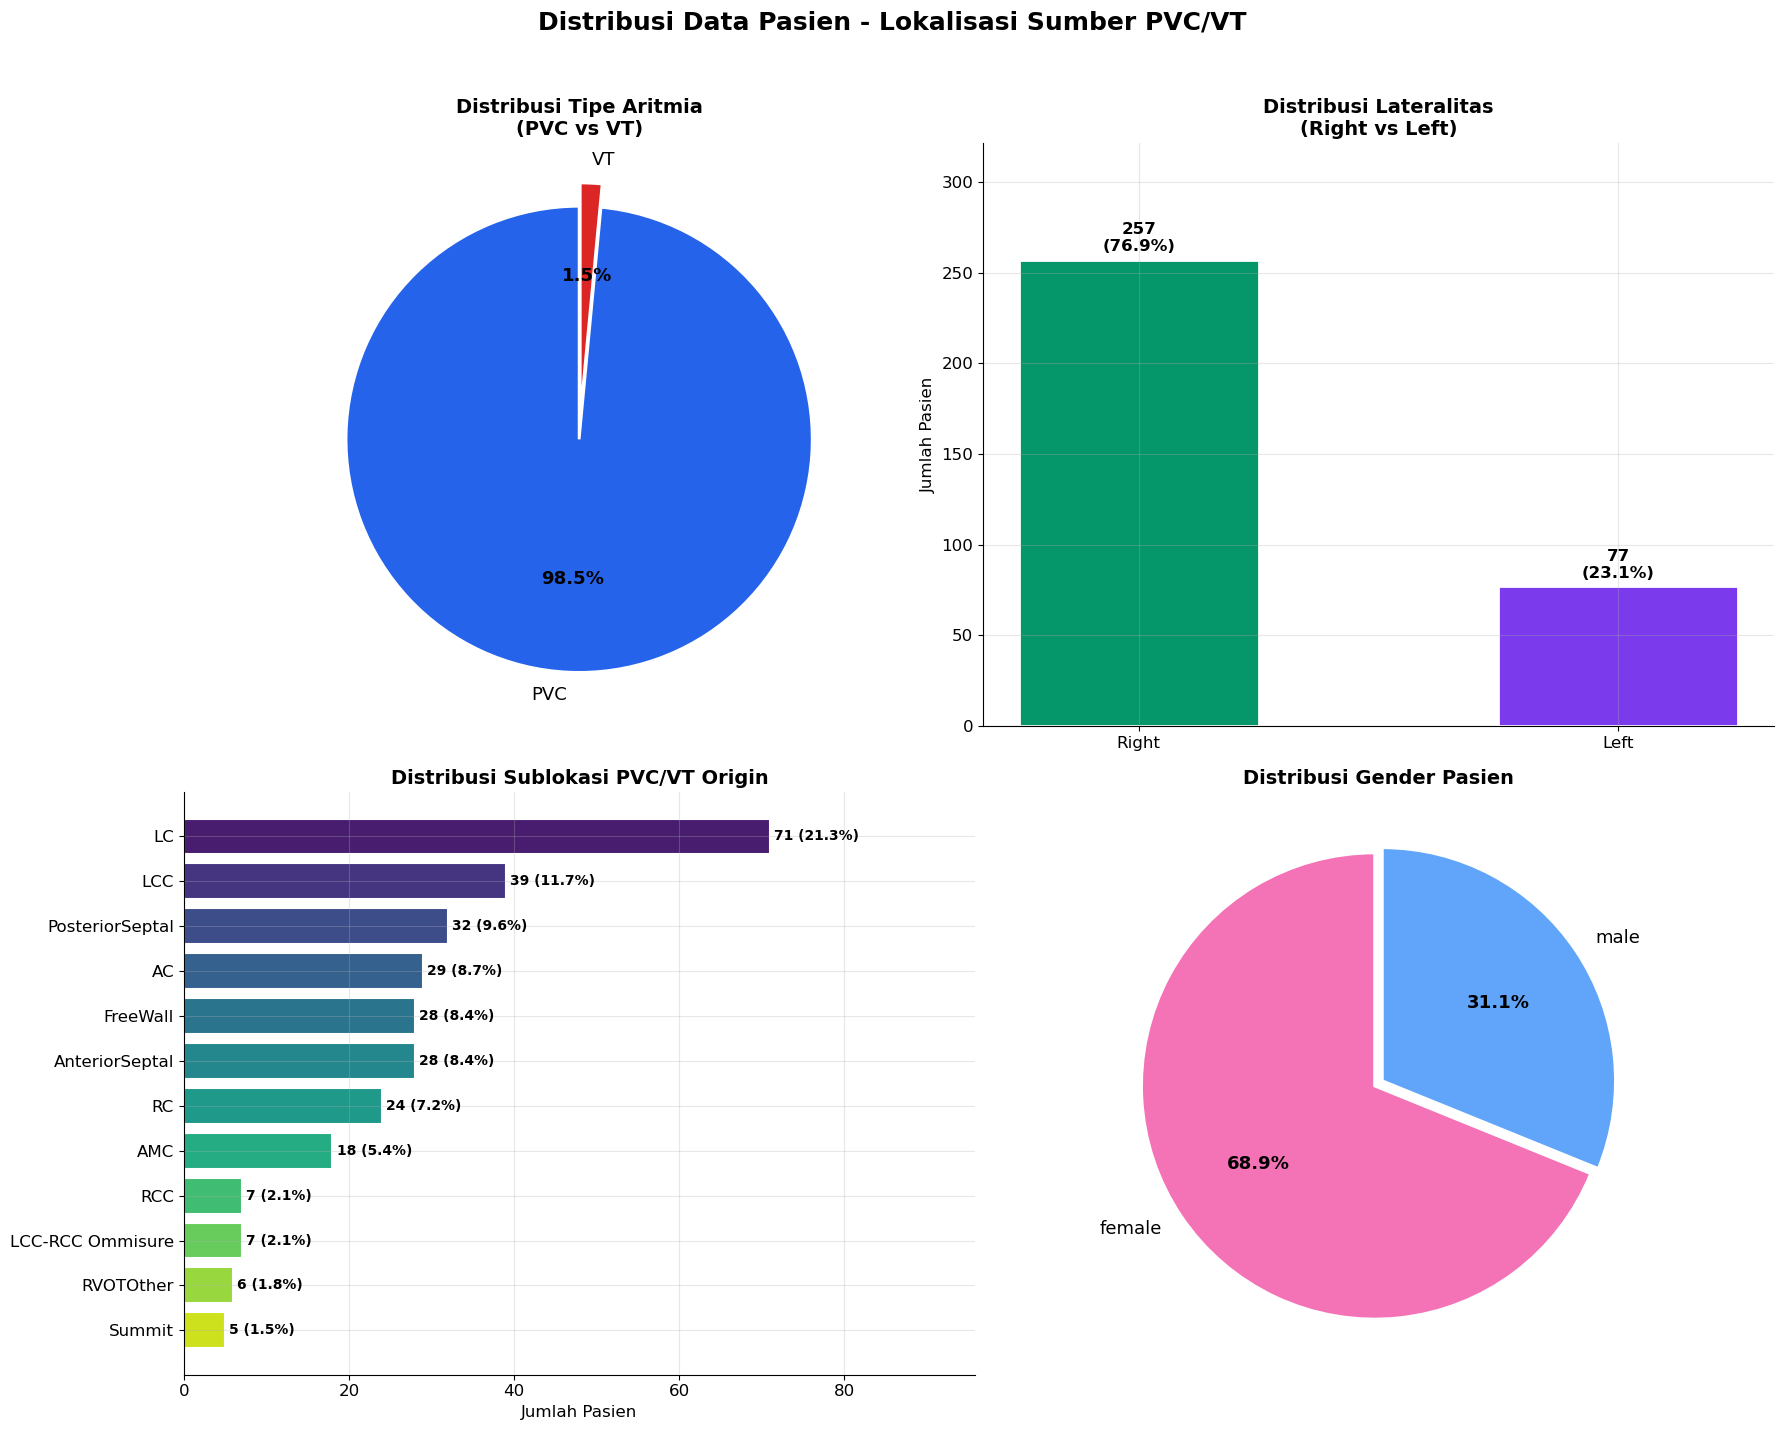

✅ Gambar disimpan: preprocessed_data/distribusi_pasien.png

──────────────────────────────────────────────────────────────────────
📝 KESIMPULAN DISTRIBUSI DATA PASIEN:
──────────────────────────────────────────────────────────────────────

1. IMBALANCE TIPE: Dataset sangat didominasi PVC (329 kasus, 98.5%)
   vs VT hanya 5 kasus (1.5%). Rasio PVC:VT = 66:1.

2. IMBALANCE LATERALITAS: Right (257, 76.9%) mendominasi
   dibanding Left (77, 23.1%). Rasio ~3.3:1.
   → Mayoritas PVC berasal dari Right Ventricular Outflow Tract (RVOT).

3. SUBLOKASI TERBANYAK: LC (71), LCC (39), PosteriorSeptal (32).
   Distribusi tidak merata → perlu stratified splitting.

4. GENDER: Female (230) > Male (104).
   Perlu diperhatikan apakah gender mempengaruhi pola EKG.



In [36]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Distribusi Data Pasien - Lokalisasi Sumber PVC/VT', 
             fontsize=18, fontweight='bold', y=1.02)

# --- Plot 1: Type Distribution (PVC vs VT) ---
ax = axes[0, 0]
type_counts = df_diagnosis['Type'].value_counts()
colors_type = ['#2563EB', '#DC2626']
wedges, texts, autotexts = ax.pie(type_counts, labels=type_counts.index, 
                                   autopct='%1.1f%%', startangle=90,
                                   colors=colors_type, textprops={'fontsize': 13},
                                   wedgeprops={'edgecolor': 'white', 'linewidth': 2},
                                   explode=[0.02, 0.08])
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax.set_title('Distribusi Tipe Aritmia\n(PVC vs VT)', fontsize=14, fontweight='bold')

# --- Plot 2: LeftRight Distribution ---
ax = axes[0, 1]
lr_counts = df_diagnosis['LeftRight'].value_counts()
bars = ax.bar(lr_counts.index, lr_counts.values, color=['#059669', '#7C3AED'],
              edgecolor='white', linewidth=2, width=0.5)
for bar, count in zip(bars, lr_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
            f'{count}\n({count/len(df_diagnosis)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Distribusi Lateralitas\n(Right vs Left)', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Pasien')
ax.set_ylim(0, max(lr_counts.values) * 1.25)
ax.spines[['top', 'right']].set_visible(False)

# --- Plot 3: Sublocation Distribution ---
ax = axes[1, 0]
sub_counts = df_diagnosis['Sublocation'].value_counts()
palette = sns.color_palette('viridis', len(sub_counts))
bars = ax.barh(sub_counts.index[::-1], sub_counts.values[::-1], color=palette[::-1],
               edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, sub_counts.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{count} ({count/len(df_diagnosis)*100:.1f}%)',
            ha='left', va='center', fontweight='bold', fontsize=10)
ax.set_title('Distribusi Sublokasi PVC/VT Origin', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Pasien')
ax.set_xlim(0, max(sub_counts.values) * 1.35)
ax.spines[['top', 'right']].set_visible(False)

# --- Plot 4: Gender Distribution ---
ax = axes[1, 1]
gender_counts = df_diagnosis['Gender'].value_counts()
colors_gender = ['#F472B6', '#60A5FA']
wedges, texts, autotexts = ax.pie(gender_counts, labels=gender_counts.index,
                                   autopct='%1.1f%%', startangle=90,
                                   colors=colors_gender, textprops={'fontsize': 13},
                                   wedgeprops={'edgecolor': 'white', 'linewidth': 2},
                                   explode=[0.02, 0.02])
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax.set_title('Distribusi Gender Pasien', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'distribusi_pasien.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: preprocessed_data/distribusi_pasien.png")

# Kesimpulan Distribusi
print("\n" + "─" * 70)
print("📝 KESIMPULAN DISTRIBUSI DATA PASIEN:")
print("─" * 70)
pvc_n = (df_diagnosis['Type']=='PVC').sum()
vt_n = (df_diagnosis['Type']=='VT').sum()
right_n = (df_diagnosis['LeftRight']=='Right').sum()
left_n = (df_diagnosis['LeftRight']=='Left').sum()
top_subloc = df_diagnosis['Sublocation'].value_counts().head(3)
print(f"""
1. IMBALANCE TIPE: Dataset sangat didominasi PVC ({pvc_n} kasus, {pvc_n/len(df_diagnosis)*100:.1f}%)
   vs VT hanya {vt_n} kasus ({vt_n/len(df_diagnosis)*100:.1f}%). Rasio PVC:VT = {pvc_n/max(vt_n,1):.0f}:1.

2. IMBALANCE LATERALITAS: Right ({right_n}, {right_n/len(df_diagnosis)*100:.1f}%) mendominasi
   dibanding Left ({left_n}, {left_n/len(df_diagnosis)*100:.1f}%). Rasio ~{right_n/max(left_n,1):.1f}:1.
   → Mayoritas PVC berasal dari Right Ventricular Outflow Tract (RVOT).

3. SUBLOKASI TERBANYAK: {', '.join([f'{s} ({c})' for s, c in top_subloc.items()])}.
   Distribusi tidak merata → perlu stratified splitting.

4. GENDER: Female ({(df_diagnosis['Gender']=='female').sum()}) > Male ({(df_diagnosis['Gender']=='male').sum()}).
   Perlu diperhatikan apakah gender mempengaruhi pola EKG.
""")

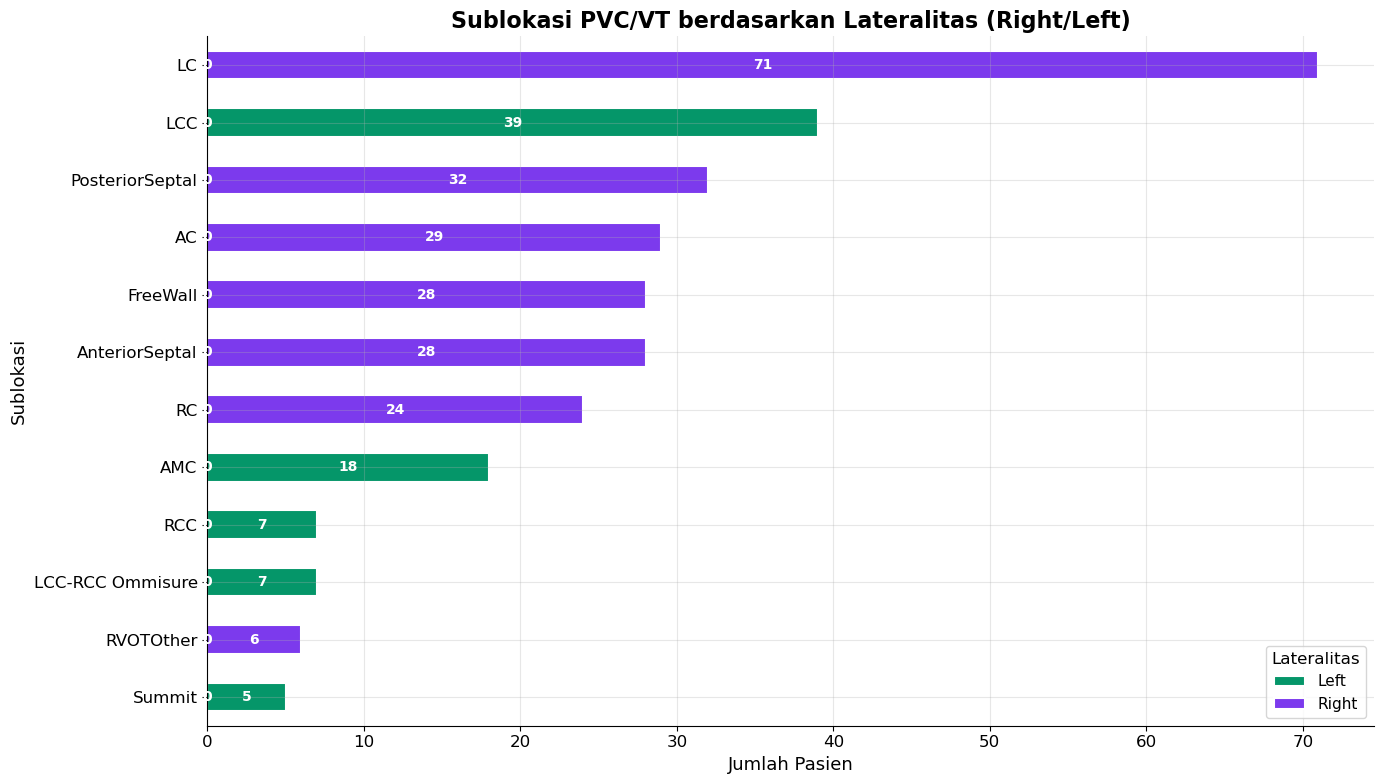

✅ Gambar disimpan: preprocessed_data/sublokasi_lateralitas.png

──────────────────────────────────────────────────────────────────────
📝 KESIMPULAN SUBLOKASI vs LATERALITAS:
──────────────────────────────────────────────────────────────────────

1. MAPPING EKSKLUSIF: Setiap sublokasi hanya muncul di SATU sisi (Right ATAU Left),
   tidak ada sublokasi yang muncul di kedua sisi.

2. SUBLOKASI RIGHT (RVOT): AC, AnteriorSeptal, FreeWall, LC, PosteriorSeptal, RC, RVOTOther
   → Merupakan area Right Ventricular Outflow Tract dan sekitarnya.

3. SUBLOKASI LEFT (LVOT): AMC, LCC, LCC-RCC Ommisure, RCC, Summit
   → Merupakan area Left Ventricular Outflow Tract (aortic cusps & summit).

4. IMPLIKASI: Label LeftRight (Right/Left) sudah cukup sebagai label utama
   untuk tahap awal lokalisasi, karena sublokasi secara natural terpisah.



In [37]:
# Crosstab: Sublocation by LeftRight
fig, ax = plt.subplots(figsize=(14, 8))

ct = pd.crosstab(df_diagnosis['Sublocation'], df_diagnosis['LeftRight'])
ct_sorted = ct.reindex(ct.sum(axis=1).sort_values(ascending=True).index)

ct_sorted.plot(kind='barh', stacked=True, ax=ax, 
               color=['#059669', '#7C3AED'], edgecolor='white', linewidth=1.5)

ax.set_title('Sublokasi PVC/VT berdasarkan Lateralitas (Right/Left)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Jumlah Pasien', fontsize=13)
ax.set_ylabel('Sublokasi', fontsize=13)
ax.legend(title='Lateralitas', fontsize=11, title_fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontweight='bold', fontsize=10, color='white')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'sublokasi_lateralitas.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar disimpan: preprocessed_data/sublokasi_lateralitas.png")

# Kesimpulan Crosstab
print("\n" + "─" * 70)
print("📝 KESIMPULAN SUBLOKASI vs LATERALITAS:")
print("─" * 70)
right_subs = sorted(df_diagnosis[df_diagnosis['LeftRight']=='Right']['Sublocation'].dropna().unique())
left_subs = sorted(df_diagnosis[df_diagnosis['LeftRight']=='Left']['Sublocation'].dropna().unique())
print(f"""
1. MAPPING EKSKLUSIF: Setiap sublokasi hanya muncul di SATU sisi (Right ATAU Left),
   tidak ada sublokasi yang muncul di kedua sisi.

2. SUBLOKASI RIGHT (RVOT): {', '.join(right_subs)}
   → Merupakan area Right Ventricular Outflow Tract dan sekitarnya.

3. SUBLOKASI LEFT (LVOT): {', '.join(left_subs)}
   → Merupakan area Left Ventricular Outflow Tract (aortic cusps & summit).

4. IMPLIKASI: Label LeftRight (Right/Left) sudah cukup sebagai label utama
   untuk tahap awal lokalisasi, karena sublokasi secara natural terpisah.
""")

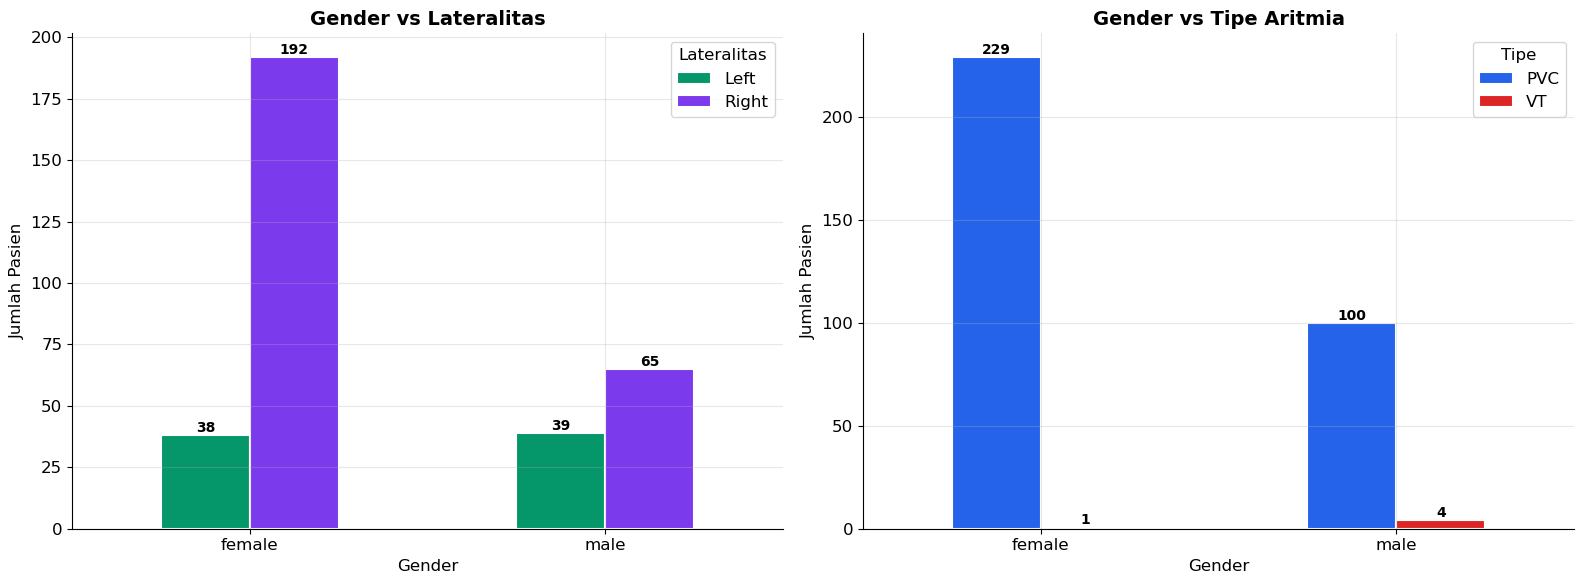


──────────────────────────────────────────────────────────────────────
📝 KESIMPULAN ANALISIS GENDER:
──────────────────────────────────────────────────────────────────────

1. DISTRIBUSI GENDER: Dataset didominasi female (230/334).
   Ini perlu dipertimbangkan dalam interpretasi hasil model.

2. GENDER vs LATERALITAS: Proporsi Right vs Left relatif konsisten
   di kedua gender → Gender kemungkinan bukan confounding factor utama
   untuk prediksi lateralitas.

3. GENDER vs TIPE: Baik PVC maupun VT lebih banyak pada female,
   sesuai dengan proporsi gender keseluruhan dataset.



In [38]:
# Cross-tab: Gender by LeftRight
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gender vs LeftRight
ct_gender_lr = pd.crosstab(df_diagnosis['Gender'], df_diagnosis['LeftRight'])
ct_gender_lr.plot(kind='bar', ax=axes[0], color=['#059669', '#7C3AED'],
                  edgecolor='white', linewidth=1.5, rot=0)
axes[0].set_title('Gender vs Lateralitas', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].legend(title='Lateralitas')
axes[0].spines[['top', 'right']].set_visible(False)
for container in axes[0].containers:
    axes[0].bar_label(container, fontweight='bold', fontsize=10)

# Gender vs Type
ct_gender_type = pd.crosstab(df_diagnosis['Gender'], df_diagnosis['Type'])
ct_gender_type.plot(kind='bar', ax=axes[1], color=['#2563EB', '#DC2626'],
                    edgecolor='white', linewidth=1.5, rot=0)
axes[1].set_title('Gender vs Tipe Aritmia', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Jumlah Pasien')
axes[1].legend(title='Tipe')
axes[1].spines[['top', 'right']].set_visible(False)
for container in axes[1].containers:
    axes[1].bar_label(container, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'gender_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# Kesimpulan Gender
print("\n" + "─" * 70)
print("📝 KESIMPULAN ANALISIS GENDER:")
print("─" * 70)
print(f"""
1. DISTRIBUSI GENDER: Dataset didominasi female ({(df_diagnosis['Gender']=='female').sum()}/{len(df_diagnosis)}).
   Ini perlu dipertimbangkan dalam interpretasi hasil model.

2. GENDER vs LATERALITAS: Proporsi Right vs Left relatif konsisten
   di kedua gender → Gender kemungkinan bukan confounding factor utama
   untuk prediksi lateralitas.

3. GENDER vs TIPE: Baik PVC maupun VT lebih banyak pada female,
   sesuai dengan proporsi gender keseluruhan dataset.
""")

---
## 4. Pencocokan Data & Deteksi Missing Data

In [39]:
# Pencocokan ID antara Diagnosis, Raw ECG, dan Processed ECG
raw_ids = set(f.stem for f in RAW_ECG_DIR.glob('*.csv'))
proc_ids = set(f.stem for f in PROCESSED_ECG_DIR.glob('*.csv'))
diag_ids = set(df_diagnosis['HospitalID'].astype(str).tolist())

print("=" * 70)
print("🔗 PENCOCOKAN DATA")
print("=" * 70)
print(f"\n📋 ID Diagnosis   : {len(diag_ids)} pasien")
print(f"📁 Raw ECG Files  : {len(raw_ids)} file")
print(f"📁 Processed ECG  : {len(proc_ids)} file")

print(f"\n✅ Semua ID cocok (Diagnosis ↔ Raw)   : {diag_ids == raw_ids}")
print(f"✅ Semua ID cocok (Diagnosis ↔ Proc)   : {diag_ids == proc_ids}")
print(f"✅ Raw == Processed files               : {raw_ids == proc_ids}")

# Check for missing
missing_raw = diag_ids - raw_ids
missing_proc = diag_ids - proc_ids
extra_raw = raw_ids - diag_ids
extra_proc = proc_ids - diag_ids

if missing_raw:
    print(f"\n⚠️ ID di Diagnosis tapi TIDAK ada di Raw ECG: {missing_raw}")
else:
    print(f"\n✅ Semua pasien memiliki data Raw ECG")

if missing_proc:
    print(f"⚠️ ID di Diagnosis tapi TIDAK ada di Processed ECG: {missing_proc}")
else:
    print(f"✅ Semua pasien memiliki data Processed ECG")

if extra_raw:
    print(f"⚠️ File Raw ECG tanpa Diagnosis: {extra_raw}")

if extra_proc:
    print(f"⚠️ File Processed ECG tanpa Diagnosis: {extra_proc}")

🔗 PENCOCOKAN DATA

📋 ID Diagnosis   : 334 pasien
📁 Raw ECG Files  : 334 file
📁 Processed ECG  : 334 file

✅ Semua ID cocok (Diagnosis ↔ Raw)   : True
✅ Semua ID cocok (Diagnosis ↔ Proc)   : True
✅ Raw == Processed files               : True

✅ Semua pasien memiliki data Raw ECG
✅ Semua pasien memiliki data Processed ECG


❓ ANALISIS MISSING VALUES

📊 Missing Values per Kolom:
   ✅ HospitalID: 0 (0.0%)
   ✅ Type: 0 (0.0%)
   ✅ LeftRight: 0 (0.0%)
   ⚠️ Sublocation: 40 (12.0%)
   ✅ Gender: 0 (0.0%)

📋 Detail pasien dengan Sublocation kosong (40 pasien):
 HospitalID Type LeftRight Gender
     822003  PVC     Right female
     829049  PVC     Right   male
     832701  PVC     Right female
     831663  PVC     Right female
     838811  PVC     Right female
     838955   VT     Right   male
     839103  PVC     Right female
     839361  PVC     Right female
     840221  PVC     Right female
     840297  PVC     Right female
     841624  PVC     Right female
     847596  PVC     Right female
     848620  PVC     Right female
     848517  PVC     Right   male
     848545  PVC     Right female
     849027  PVC     Right   male
     874164   VT     Right   male
     883440  PVC     Right   male
     886784  PVC     Right female
     897211  PVC     Right female
     898498  PVC     Right female
     902131  PVC  

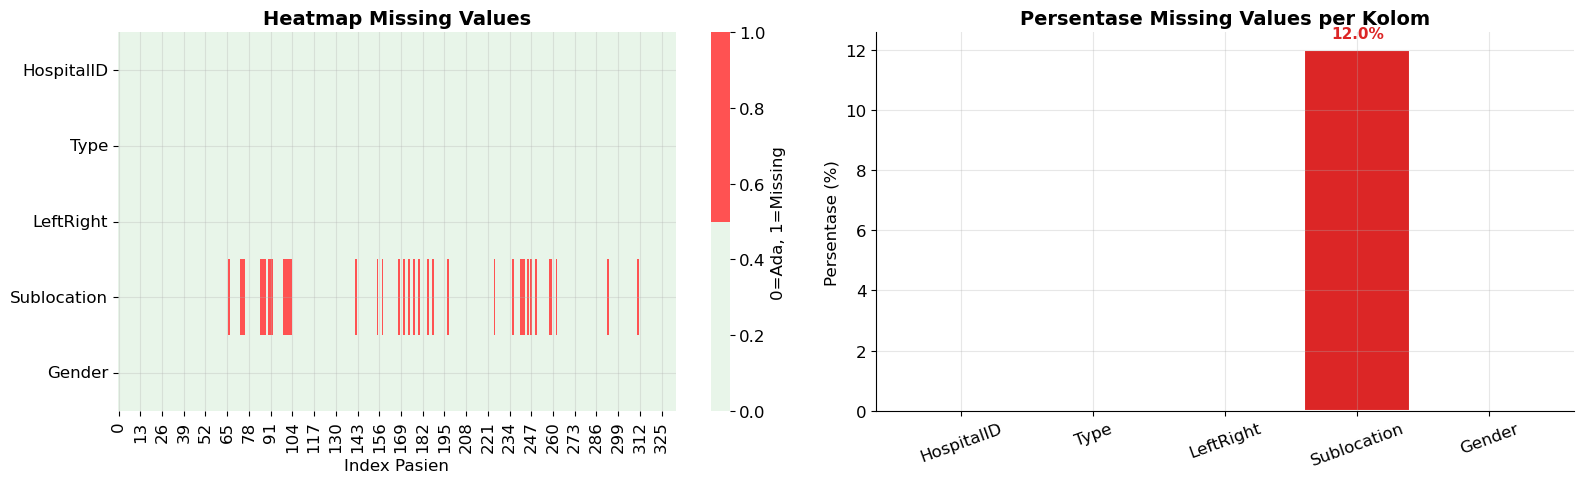


──────────────────────────────────────────────────────────────────────
📝 KESIMPULAN MISSING VALUES:
──────────────────────────────────────────────────────────────────────

1. HANYA Sublocation yang memiliki missing values (40/334, 12.0%).
   Kolom lain (HospitalID, Type, LeftRight, Gender) lengkap 100%.

2. Semua 40 pasien dengan Sublocation kosong TETAP memiliki label LeftRight.
   → Label LeftRight dapat digunakan untuk semua pasien tanpa data loss.

3. IMPLIKASI UNTUK MODELING:
   - Jika menggunakan LeftRight sebagai label: 0% data loss
   - Jika menggunakan Sublocation sebagai label: 40 pasien harus di-drop
   → Disarankan menggunakan LeftRight sebagai label utama untuk baseline.



In [40]:
# Analisis Missing Values di Diagnosis
print("=" * 70)
print("❓ ANALISIS MISSING VALUES")
print("=" * 70)

null_counts = df_diagnosis.isnull().sum()
print(f"\n📊 Missing Values per Kolom:")
for col, n_null in null_counts.items():
    status = "✅" if n_null == 0 else "⚠️"
    print(f"   {status} {col}: {n_null} ({n_null/len(df_diagnosis)*100:.1f}%)")

# Detail sublocation missing
null_subloc = df_diagnosis[df_diagnosis['Sublocation'].isnull()]
print(f"\n📋 Detail pasien dengan Sublocation kosong ({len(null_subloc)} pasien):")
print(null_subloc[['HospitalID', 'Type', 'LeftRight', 'Gender']].to_string(index=False))

# Visualisasi Missing Values
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap missing
ax = axes[0]
missing_matrix = df_diagnosis.isnull().astype(int)
sns.heatmap(missing_matrix.T, cbar=True, yticklabels=df_diagnosis.columns,
            cmap=['#E8F5E9', '#FF5252'], ax=ax, cbar_kws={'label': '0=Ada, 1=Missing'})
ax.set_title('Heatmap Missing Values', fontsize=14, fontweight='bold')
ax.set_xlabel('Index Pasien')

# Bar missing
ax = axes[1]
null_pct = (df_diagnosis.isnull().sum() / len(df_diagnosis) * 100)
colors = ['#059669' if v == 0 else '#DC2626' for v in null_pct.values]
bars = ax.bar(null_pct.index, null_pct.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, null_pct.values):
    if pct > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11, color='#DC2626')
ax.set_title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
ax.set_ylabel('Persentase (%)')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()

# Kesimpulan Missing Values
print("\n" + "─" * 70)
print("📝 KESIMPULAN MISSING VALUES:")
print("─" * 70)
n_missing_subloc = df_diagnosis['Sublocation'].isnull().sum()
print(f"""
1. HANYA Sublocation yang memiliki missing values ({n_missing_subloc}/{len(df_diagnosis)}, {n_missing_subloc/len(df_diagnosis)*100:.1f}%).
   Kolom lain (HospitalID, Type, LeftRight, Gender) lengkap 100%.

2. Semua {n_missing_subloc} pasien dengan Sublocation kosong TETAP memiliki label LeftRight.
   → Label LeftRight dapat digunakan untuk semua pasien tanpa data loss.

3. IMPLIKASI UNTUK MODELING:
   - Jika menggunakan LeftRight sebagai label: 0% data loss
   - Jika menggunakan Sublocation sebagai label: {n_missing_subloc} pasien harus di-drop
   → Disarankan menggunakan LeftRight sebagai label utama untuk baseline.
""")

---
## 5. Analisis Sinyal EKG (Raw & Processed)

In [41]:
# Fungsi untuk memuat dan memvisualisasikan sinyal EKG 12-Lead
def load_ecg(hospital_id, ecg_dir):
    """Memuat data EKG berdasarkan Hospital ID."""
    filepath = ecg_dir / f"{hospital_id}.csv"
    return pd.read_csv(filepath)

def plot_12lead_ecg(ecg_data, hospital_id, title_suffix="", duration_sec=5, start_sec=0, fs=1000):
    """Visualisasi EKG 12-Lead dalam format standar klinis."""
    standard_order = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    
    start_idx = int(start_sec * fs)
    end_idx = min(start_idx + int(duration_sec * fs), len(ecg_data))
    time = np.arange(start_idx, end_idx) / fs
    
    fig, axes = plt.subplots(6, 2, figsize=(20, 18))
    fig.suptitle(f'EKG 12-Lead - Pasien {hospital_id} {title_suffix}\n'
                 f'(Durasi: {start_sec}s - {start_sec+duration_sec}s | '
                 f'Total Rekaman: {len(ecg_data)/fs:.1f}s)',
                 fontsize=16, fontweight='bold', y=1.02)
    
    # Layout: 6 rows x 2 columns
    lead_positions = [
        ('I', 0, 0), ('V1', 0, 1),
        ('II', 1, 0), ('V2', 1, 1),
        ('III', 2, 0), ('V3', 2, 1),
        ('aVR', 3, 0), ('V4', 3, 1),
        ('aVL', 4, 0), ('V5', 4, 1),
        ('aVF', 5, 0), ('V6', 5, 1),
    ]
    
    for lead_name, row, col in lead_positions:
        ax = axes[row, col]
        lead_data = ecg_data[lead_name].values[start_idx:end_idx]
        color = LEAD_COLORS.get(lead_name, '#333333')
        
        ax.plot(time, lead_data, color=color, linewidth=0.7, alpha=0.9)
        ax.set_ylabel(lead_name, fontsize=13, fontweight='bold', rotation=0, labelpad=30)
        ax.set_xlim(time[0], time[-1])
        ax.axhline(y=0, color='gray', linewidth=0.3, linestyle='--')
        ax.grid(True, alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)
        
        if row == 5:
            ax.set_xlabel('Waktu (detik)', fontsize=11)
        else:
            ax.set_xticklabels([])
    
    plt.tight_layout()
    return fig

### 5.1 Visualisasi Sinyal EKG Raw (Contoh Pasien)

In [42]:
# Pilih beberapa sampel pasien dari berbagai sublokasi
sample_patients = []
for subloc in df_diagnosis['Sublocation'].dropna().unique()[:4]:
    pid = df_diagnosis[df_diagnosis['Sublocation'] == subloc]['HospitalID'].iloc[0]
    sample_patients.append((pid, subloc))

print("📊 Sampel pasien yang akan divisualisasikan:")
for pid, subloc in sample_patients:
    lr = df_diagnosis[df_diagnosis['HospitalID'] == pid]['LeftRight'].iloc[0]
    print(f"   • ID {pid} - {subloc} ({lr})")

📊 Sampel pasien yang akan divisualisasikan:
   • ID 702840 - PosteriorSeptal (Right)
   • ID 707971 - FreeWall (Right)
   • ID 740908 - RVOTOther (Right)
   • ID 742264 - AnteriorSeptal (Right)


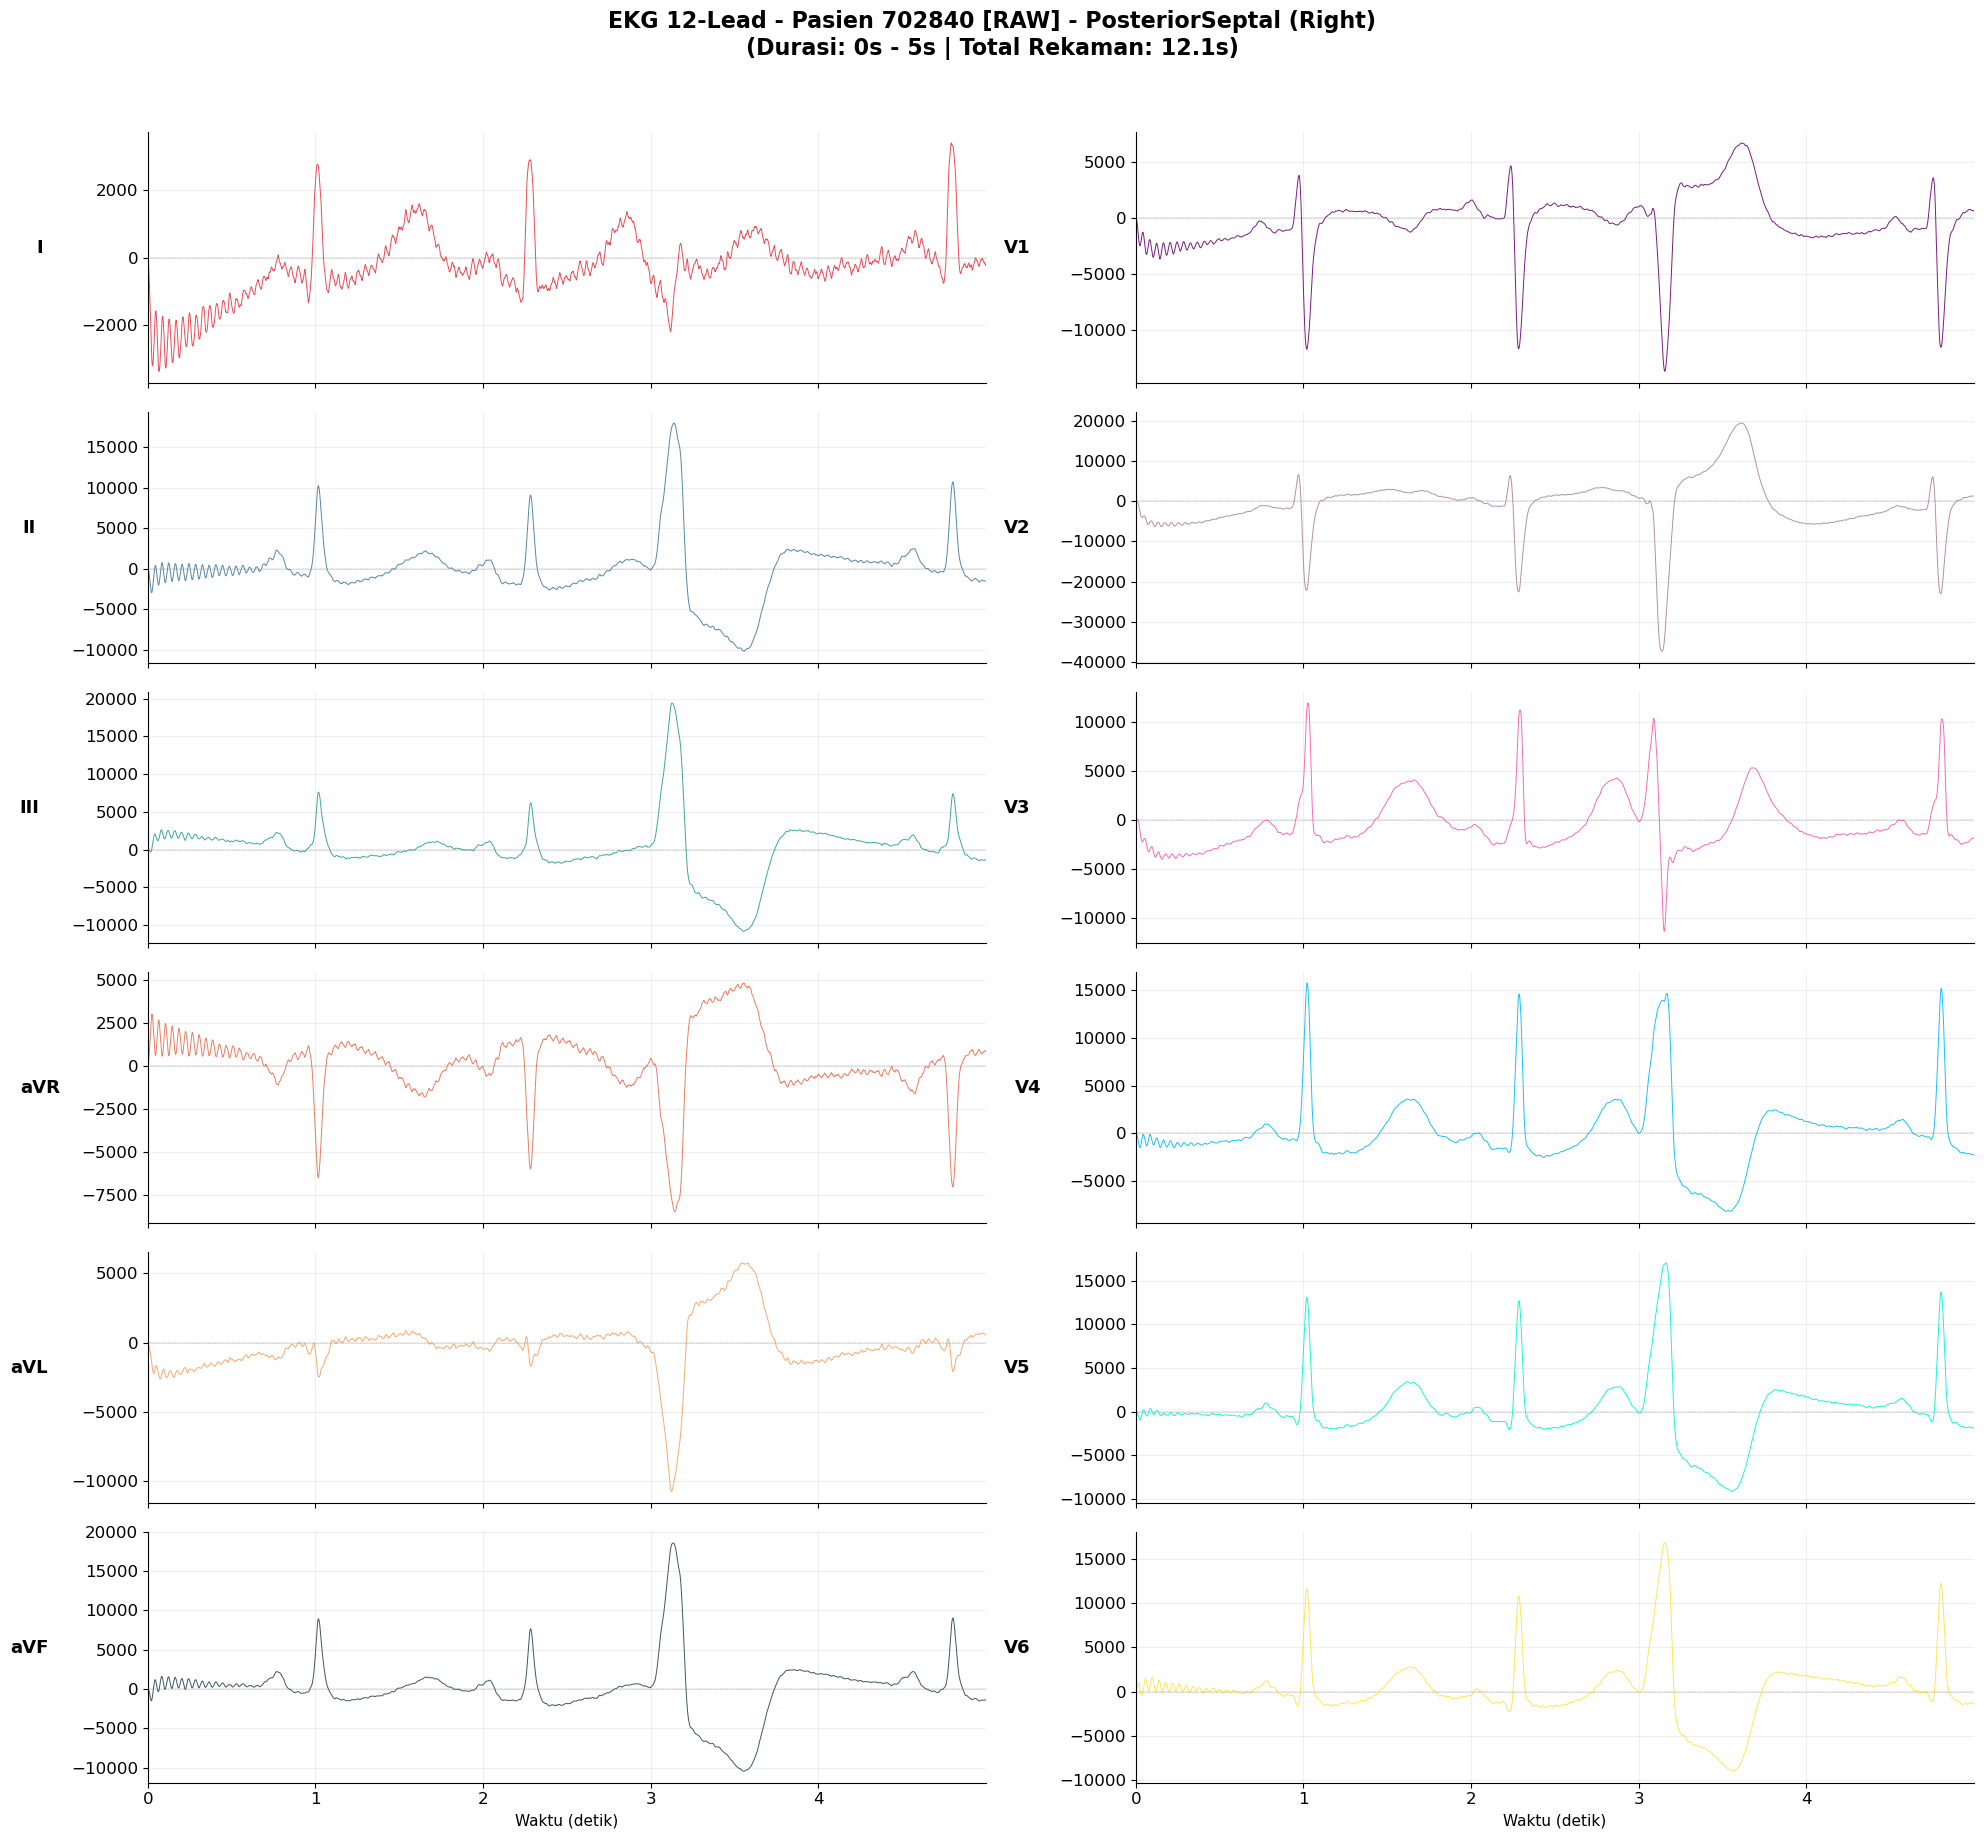

✅ Raw ECG shape: (12104, 12)


In [43]:
# Plot EKG Raw untuk pasien pertama
pid, subloc = sample_patients[0]
lr = df_diagnosis[df_diagnosis['HospitalID'] == pid]['LeftRight'].iloc[0]
ecg_raw = load_ecg(pid, RAW_ECG_DIR)
fig = plot_12lead_ecg(ecg_raw, pid, 
                      title_suffix=f"[RAW] - {subloc} ({lr})",
                      duration_sec=5, start_sec=0)
plt.savefig(str(OUTPUT_DIR / f'ecg_raw_sample_{pid}.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Raw ECG shape: {ecg_raw.shape}")

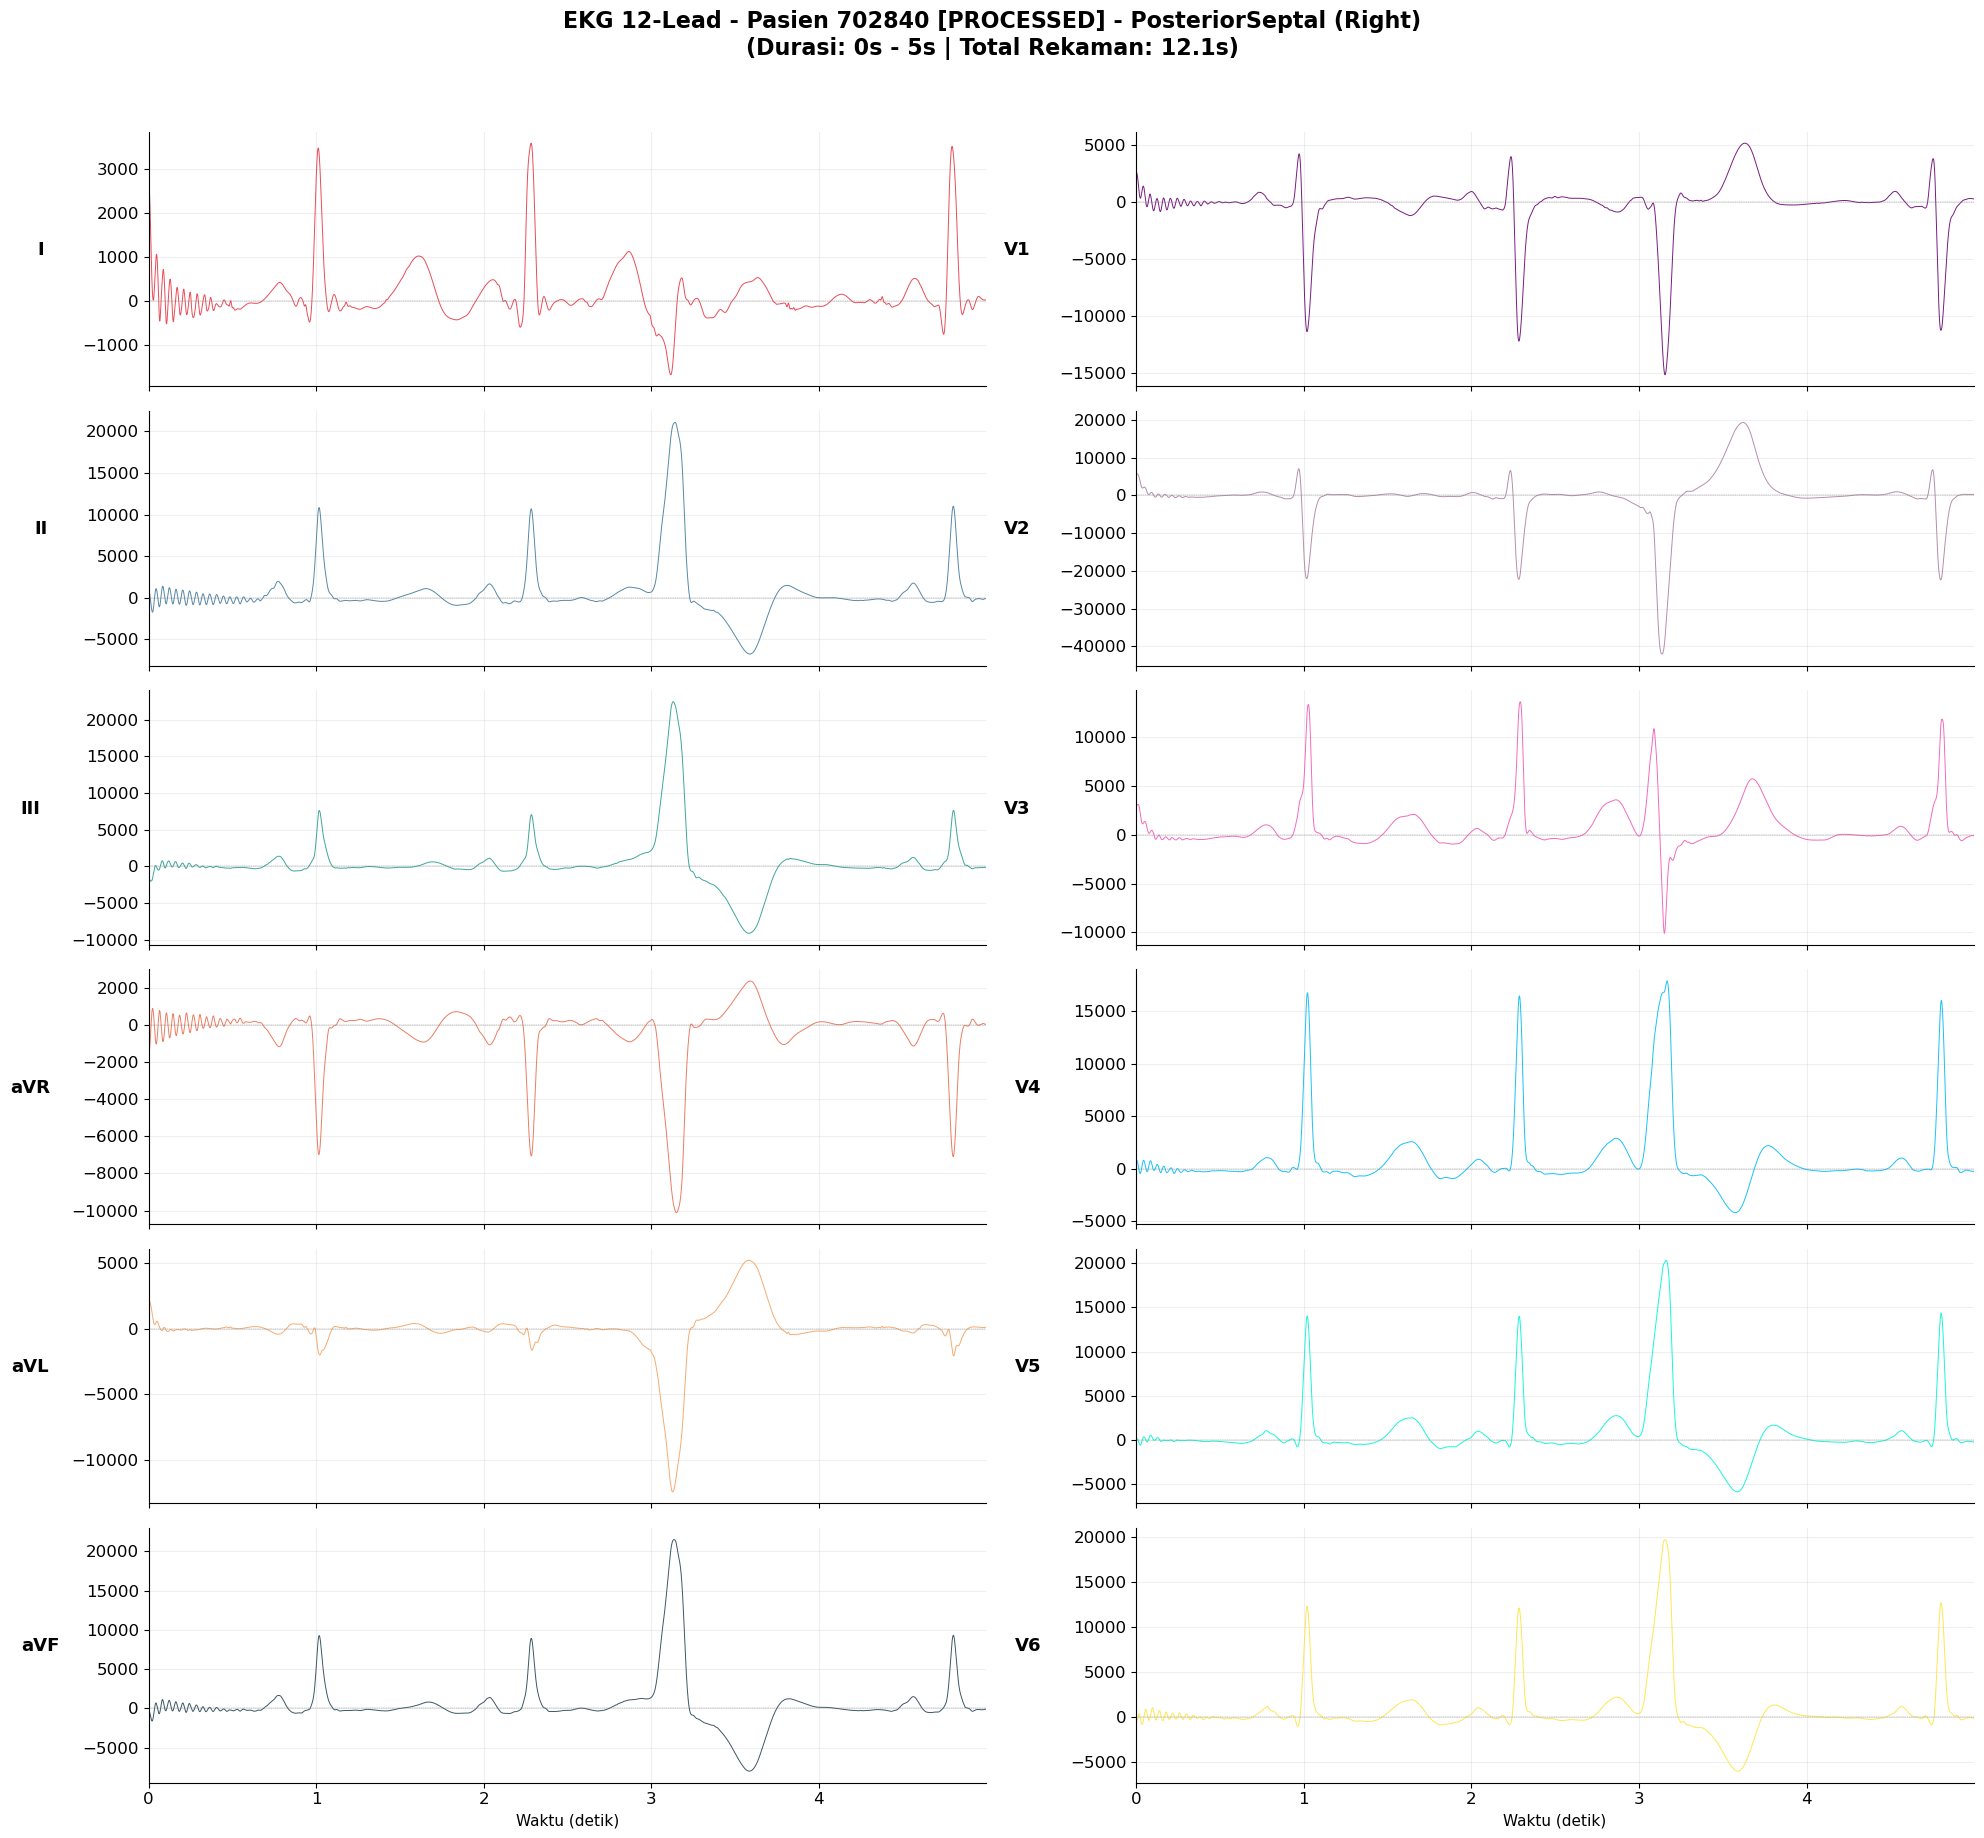

✅ Processed ECG shape: (12104, 12)


In [44]:
# Plot EKG Processed untuk pasien yang sama
ecg_proc = load_ecg(pid, PROCESSED_ECG_DIR)
fig = plot_12lead_ecg(ecg_proc, pid,
                      title_suffix=f"[PROCESSED] - {subloc} ({lr})",
                      duration_sec=5, start_sec=0)
plt.savefig(str(OUTPUT_DIR / f'ecg_processed_sample_{pid}.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Processed ECG shape: {ecg_proc.shape}")

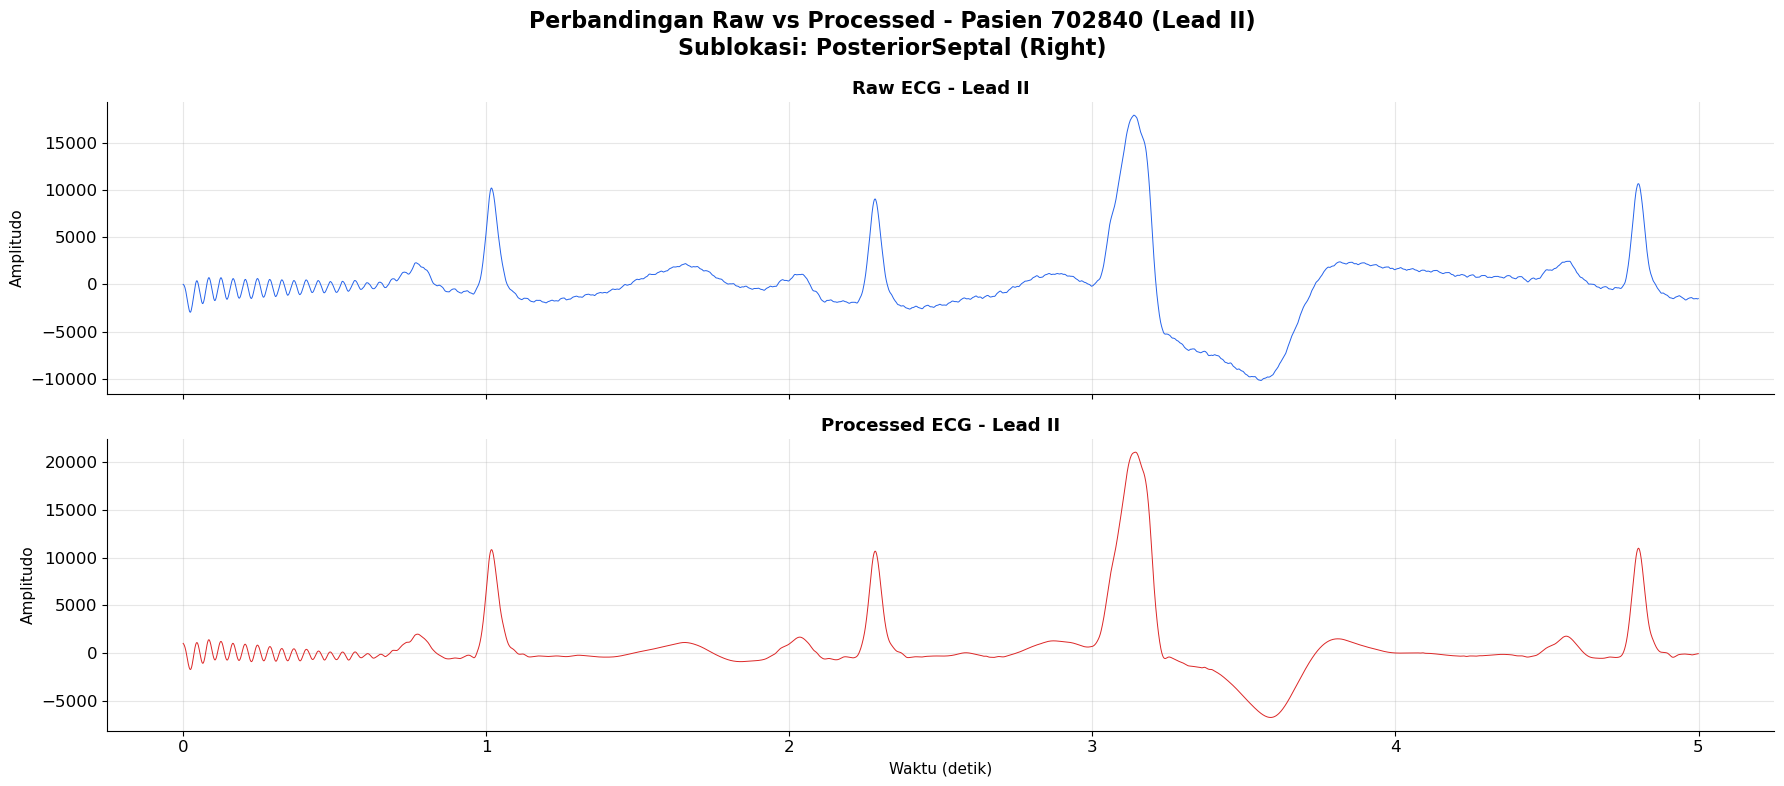

In [45]:
# Perbandingan Raw vs Processed untuk Lead II (paling informatif)
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
fig.suptitle(f'Perbandingan Raw vs Processed - Pasien {pid} (Lead II)\n'
             f'Sublokasi: {subloc} ({lr})', fontsize=16, fontweight='bold')

duration = 5  # detik
end_idx = min(duration * SAMPLING_RATE, len(ecg_raw))
time = np.arange(end_idx) / SAMPLING_RATE

axes[0].plot(time, ecg_raw['II'].values[:end_idx], color='#2563EB', linewidth=0.7)
axes[0].set_title('Raw ECG - Lead II', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amplitudo', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(time, ecg_proc['II'].values[:end_idx], color='#DC2626', linewidth=0.7)
axes[1].set_title('Processed ECG - Lead II', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amplitudo', fontsize=11)
axes[1].set_xlabel('Waktu (detik)', fontsize=11)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f'raw_vs_processed_{pid}.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Visualisasi Beberapa Pasien dari Sublokasi Berbeda

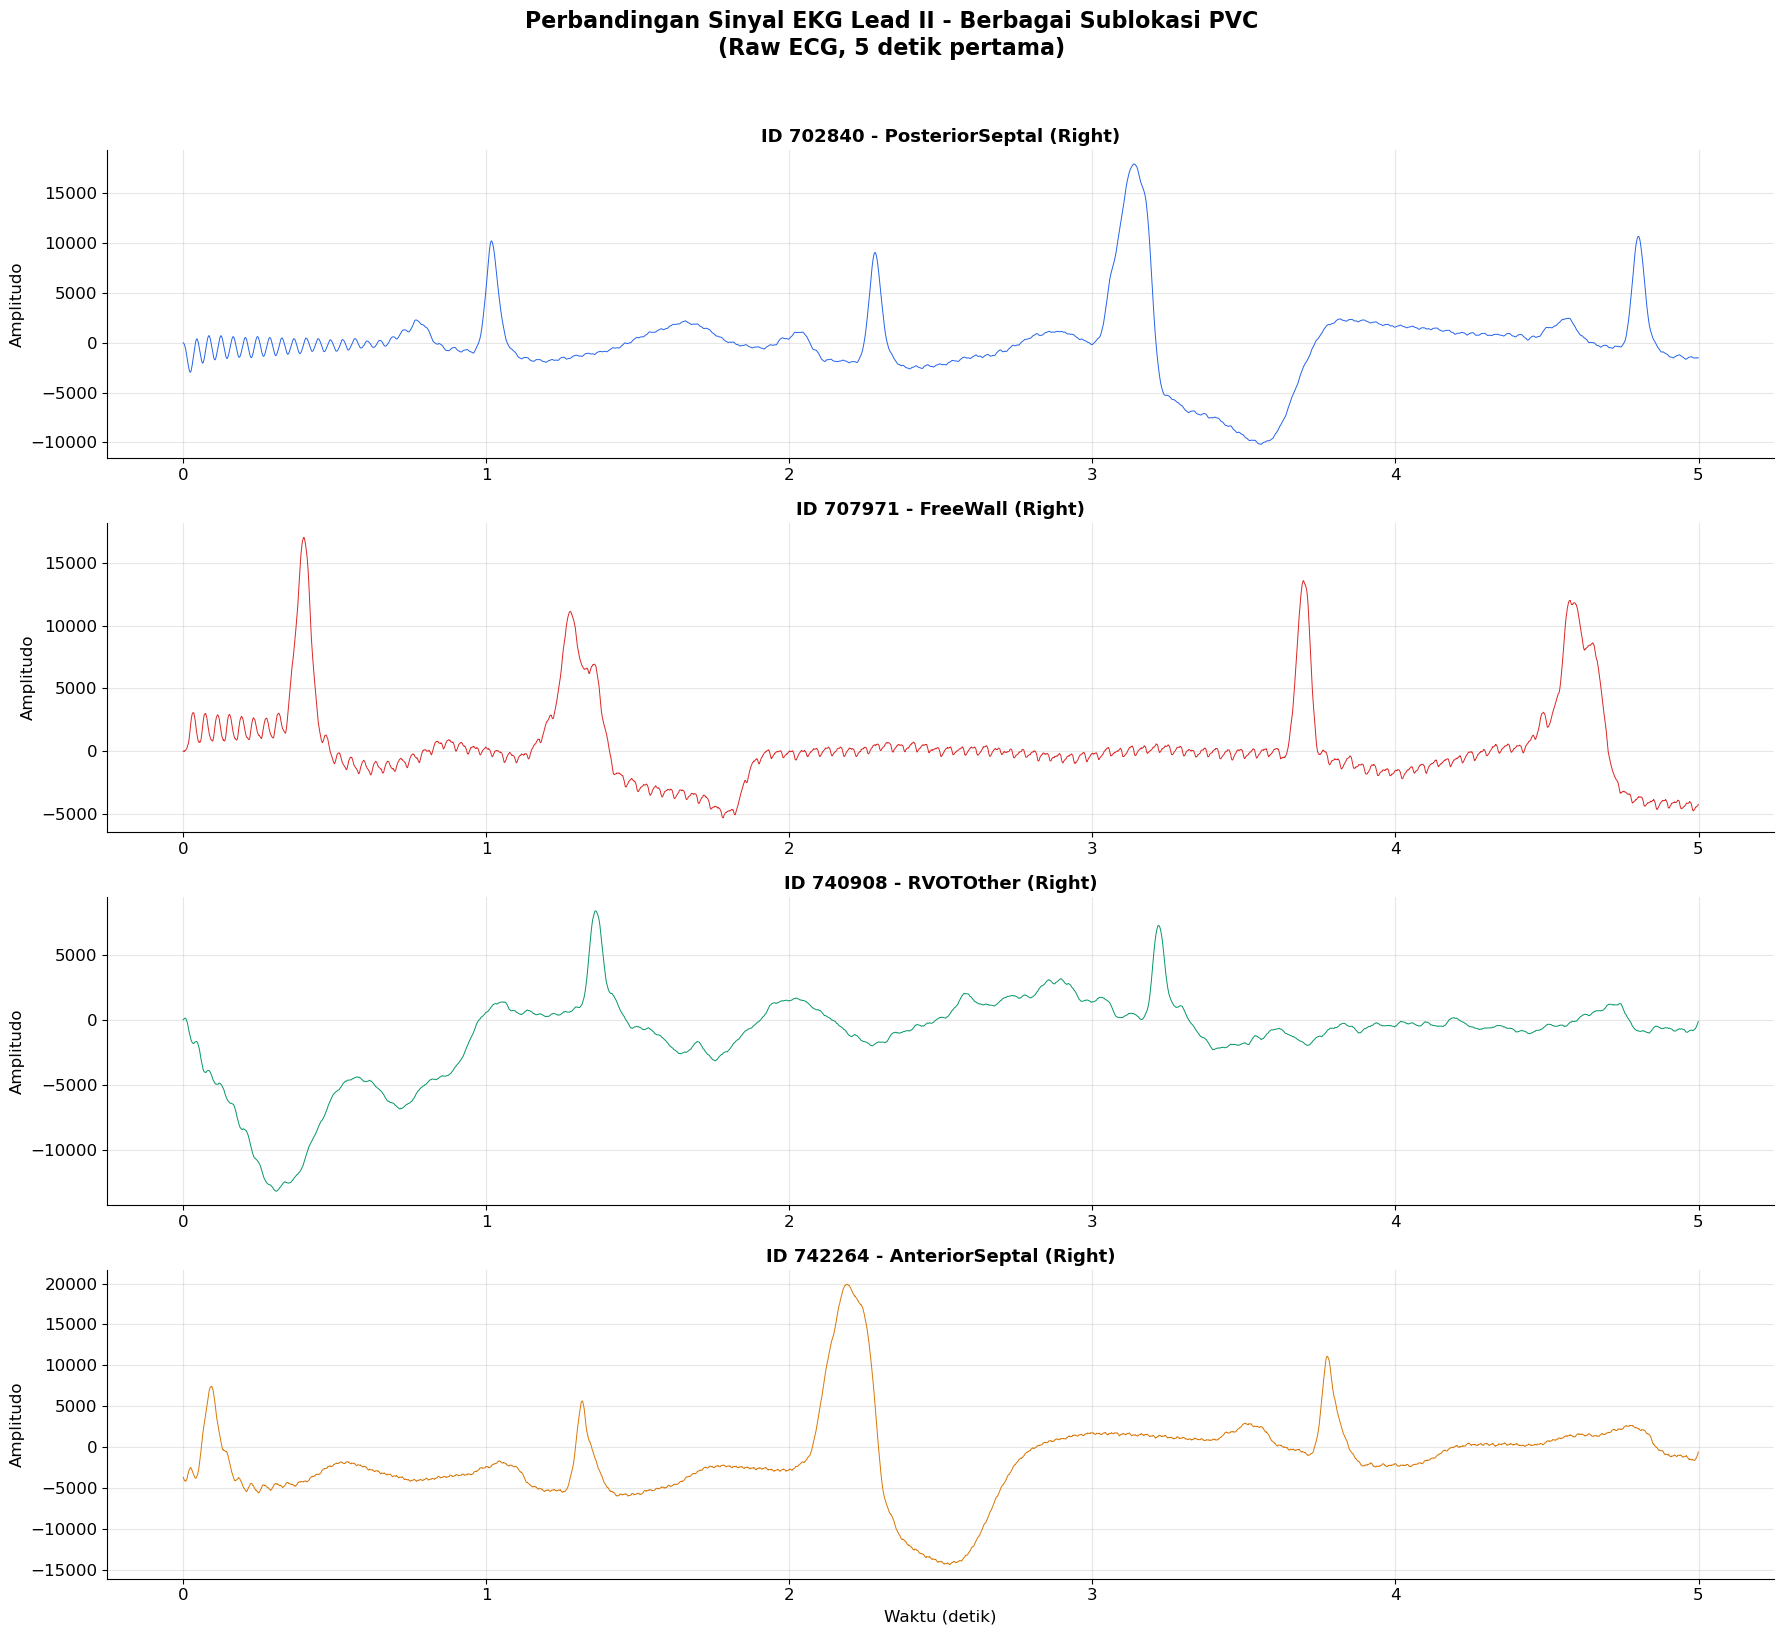

In [46]:
# Visualisasi Lead II dari 4 sublokasi berbeda (Raw ECG)
fig, axes = plt.subplots(len(sample_patients), 1, figsize=(18, 4*len(sample_patients)))
fig.suptitle('Perbandingan Sinyal EKG Lead II - Berbagai Sublokasi PVC\n(Raw ECG, 5 detik pertama)',
             fontsize=16, fontweight='bold', y=1.02)

colors_sub = ['#2563EB', '#DC2626', '#059669', '#D97706']
for i, (pid, subloc) in enumerate(sample_patients):
    lr = df_diagnosis[df_diagnosis['HospitalID'] == pid]['LeftRight'].iloc[0]
    ecg = load_ecg(pid, RAW_ECG_DIR)
    end_idx = min(5 * SAMPLING_RATE, len(ecg))
    time = np.arange(end_idx) / SAMPLING_RATE
    
    axes[i].plot(time, ecg['II'].values[:end_idx], color=colors_sub[i], linewidth=0.7)
    axes[i].set_title(f'ID {pid} - {subloc} ({lr})', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Amplitudo')
    axes[i].spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Waktu (detik)', fontsize=12)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'ecg_comparison_sublocations.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Analisis Statistik Sinyal EKG

In [47]:
# Mengumpulkan statistik dari semua pasien
print("⏳ Mengumpulkan statistik sinyal EKG dari seluruh pasien...")

ecg_stats = []
leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

for idx, row in df_diagnosis.iterrows():
    hid = row['HospitalID']
    try:
        ecg_raw = pd.read_csv(RAW_ECG_DIR / f"{hid}.csv")
        stat = {
            'HospitalID': hid,
            'Type': row['Type'],
            'LeftRight': row['LeftRight'],
            'Sublocation': row['Sublocation'],
            'Gender': row['Gender'],
            'n_samples': len(ecg_raw),
            'duration_sec': len(ecg_raw) / SAMPLING_RATE,
        }
        for lead in leads:
            stat[f'{lead}_mean'] = ecg_raw[lead].mean()
            stat[f'{lead}_std'] = ecg_raw[lead].std()
            stat[f'{lead}_min'] = ecg_raw[lead].min()
            stat[f'{lead}_max'] = ecg_raw[lead].max()
            stat[f'{lead}_range'] = ecg_raw[lead].max() - ecg_raw[lead].min()
        ecg_stats.append(stat)
    except Exception as e:
        print(f"  ❌ Error loading {hid}: {e}")

df_stats = pd.DataFrame(ecg_stats)
print(f"\n✅ Berhasil mengumpulkan statistik dari {len(df_stats)} pasien")

⏳ Mengumpulkan statistik sinyal EKG dari seluruh pasien...

✅ Berhasil mengumpulkan statistik dari 334 pasien


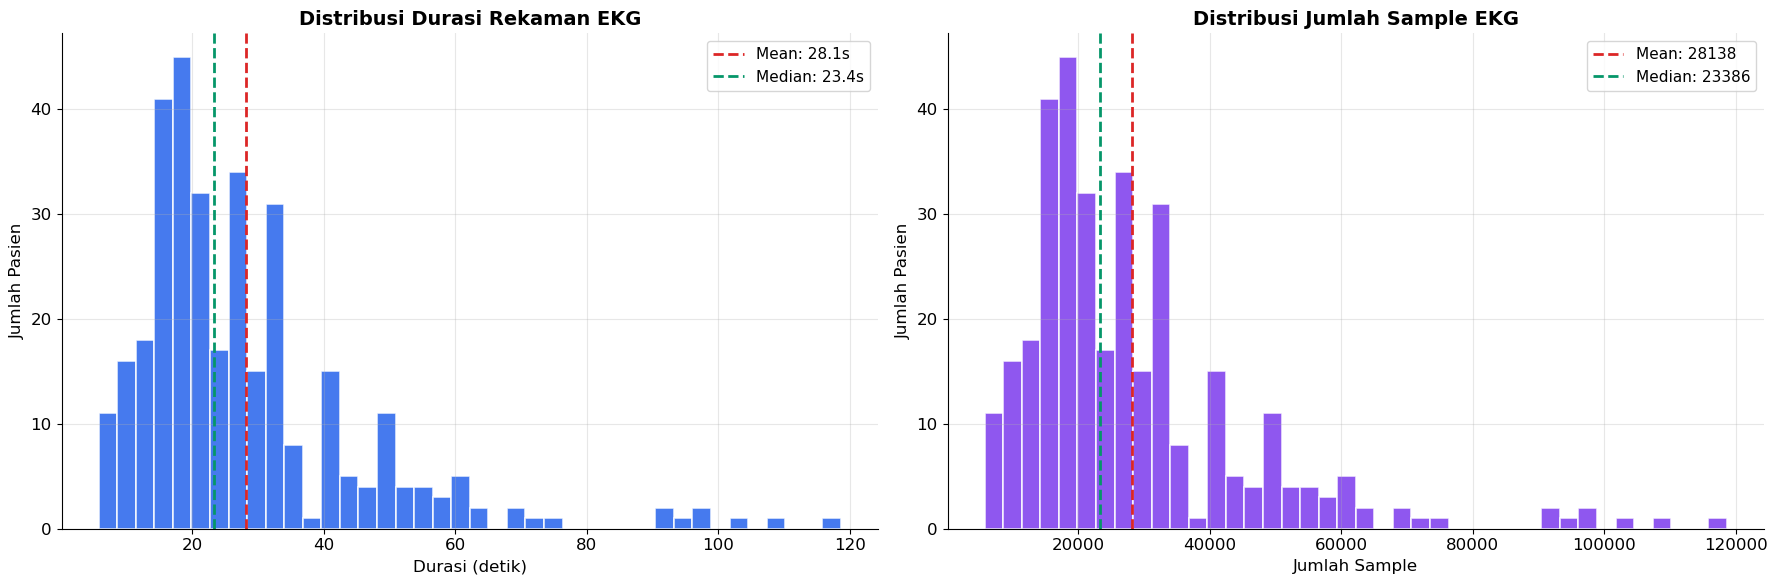


📊 Statistik Durasi Rekaman:
   Min : 5.8s (5791 samples)
   Max : 118.6s (118642 samples)
   Mean: 28.1s (28138 samples)
   Std : 17.7s


In [48]:
# Distribusi durasi rekaman EKG
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
ax.hist(df_stats['duration_sec'], bins=40, color='#2563EB', edgecolor='white',
        linewidth=1.2, alpha=0.85)
ax.axvline(df_stats['duration_sec'].mean(), color='#DC2626', linestyle='--', linewidth=2,
           label=f"Mean: {df_stats['duration_sec'].mean():.1f}s")
ax.axvline(df_stats['duration_sec'].median(), color='#059669', linestyle='--', linewidth=2,
           label=f"Median: {df_stats['duration_sec'].median():.1f}s")
ax.set_title('Distribusi Durasi Rekaman EKG', fontsize=14, fontweight='bold')
ax.set_xlabel('Durasi (detik)')
ax.set_ylabel('Jumlah Pasien')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
ax.hist(df_stats['n_samples'], bins=40, color='#7C3AED', edgecolor='white',
        linewidth=1.2, alpha=0.85)
ax.axvline(df_stats['n_samples'].mean(), color='#DC2626', linestyle='--', linewidth=2,
           label=f"Mean: {df_stats['n_samples'].mean():.0f}")
ax.axvline(df_stats['n_samples'].median(), color='#059669', linestyle='--', linewidth=2,
           label=f"Median: {df_stats['n_samples'].median():.0f}")
ax.set_title('Distribusi Jumlah Sample EKG', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Sample')
ax.set_ylabel('Jumlah Pasien')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'distribusi_durasi_ecg.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Statistik Durasi Rekaman:")
print(f"   Min : {df_stats['duration_sec'].min():.1f}s ({df_stats['n_samples'].min()} samples)")
print(f"   Max : {df_stats['duration_sec'].max():.1f}s ({df_stats['n_samples'].max()} samples)")
print(f"   Mean: {df_stats['duration_sec'].mean():.1f}s ({df_stats['n_samples'].mean():.0f} samples)")
print(f"   Std : {df_stats['duration_sec'].std():.1f}s")

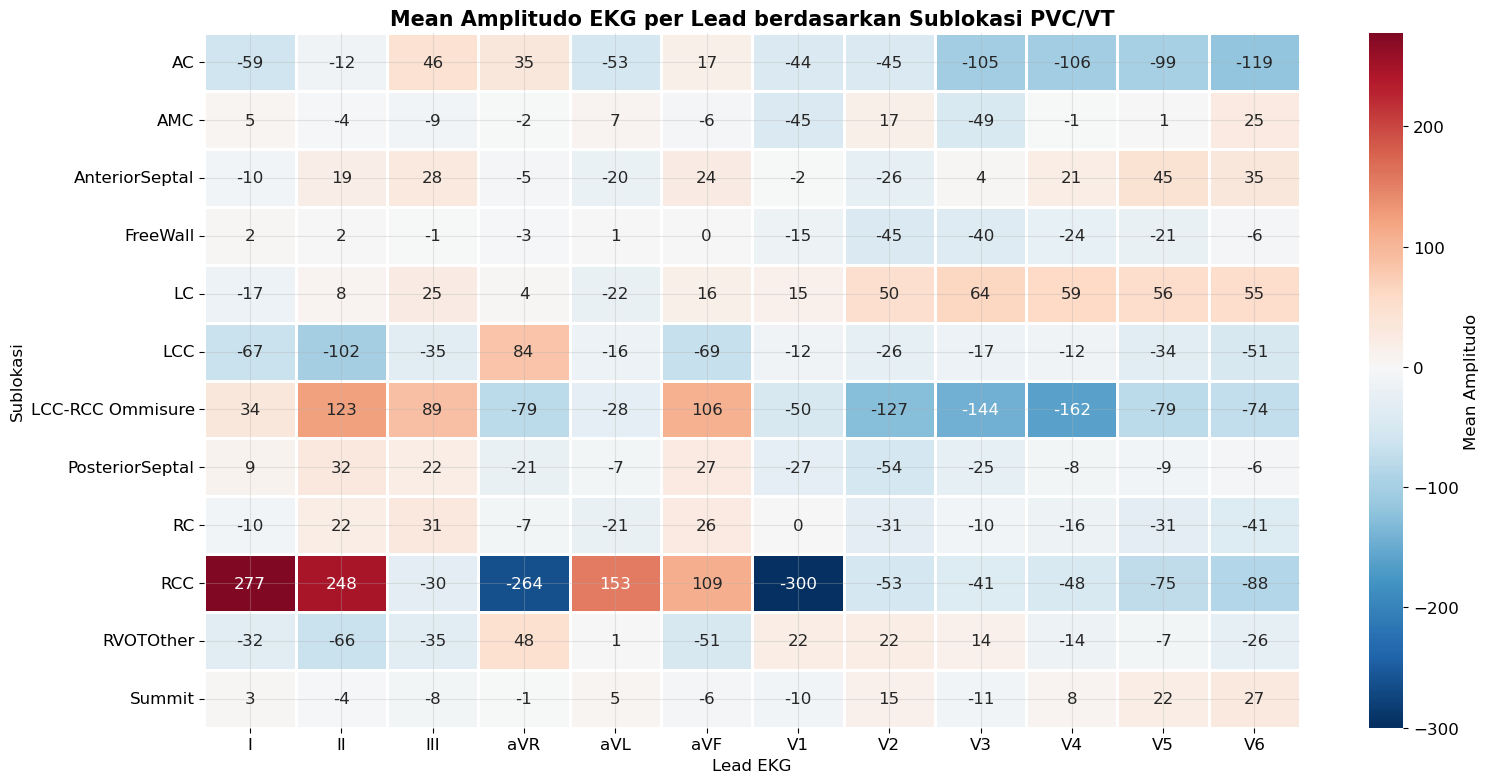

In [49]:
# Heatmap: Mean amplitudo per lead, grouped by sublocation
fig, ax = plt.subplots(figsize=(16, 8))

mean_cols = [f'{lead}_mean' for lead in leads]
df_heatmap = df_stats.dropna(subset=['Sublocation']).groupby('Sublocation')[mean_cols].mean()
df_heatmap.columns = leads

sns.heatmap(df_heatmap, annot=True, fmt='.0f', cmap='RdBu_r', center=0,
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Mean Amplitudo'})
ax.set_title('Mean Amplitudo EKG per Lead berdasarkan Sublokasi PVC/VT',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Lead EKG', fontsize=12)
ax.set_ylabel('Sublokasi', fontsize=12)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'heatmap_mean_amplitudo.png'), dpi=150, bbox_inches='tight')
plt.show()

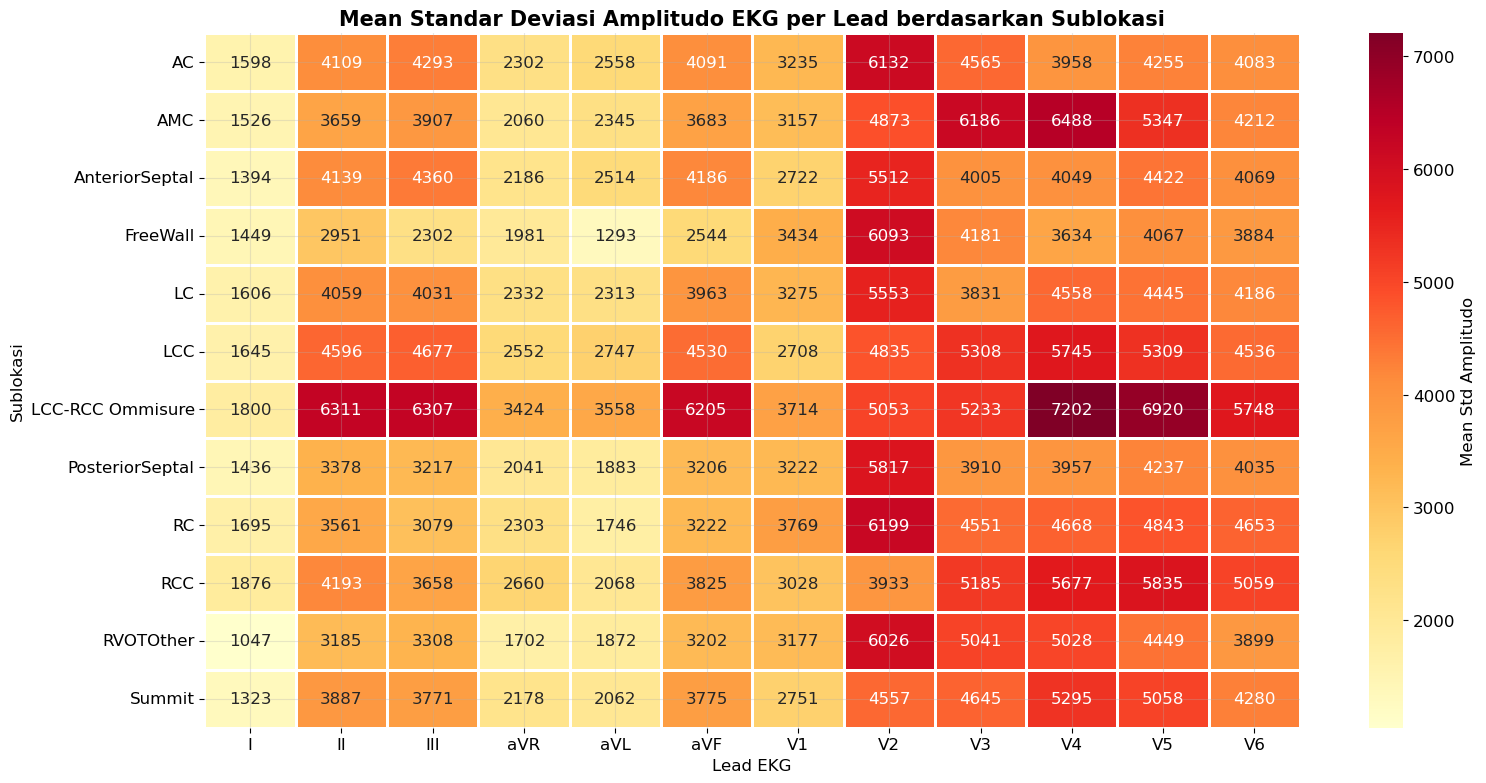

In [50]:
# Heatmap: Std amplitudo per lead, grouped by sublocation
fig, ax = plt.subplots(figsize=(16, 8))

std_cols = [f'{lead}_std' for lead in leads]
df_heatmap_std = df_stats.dropna(subset=['Sublocation']).groupby('Sublocation')[std_cols].mean()
df_heatmap_std.columns = leads

sns.heatmap(df_heatmap_std, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Mean Std Amplitudo'})
ax.set_title('Mean Standar Deviasi Amplitudo EKG per Lead berdasarkan Sublokasi',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Lead EKG', fontsize=12)
ax.set_ylabel('Sublokasi', fontsize=12)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'heatmap_std_amplitudo.png'), dpi=150, bbox_inches='tight')
plt.show()

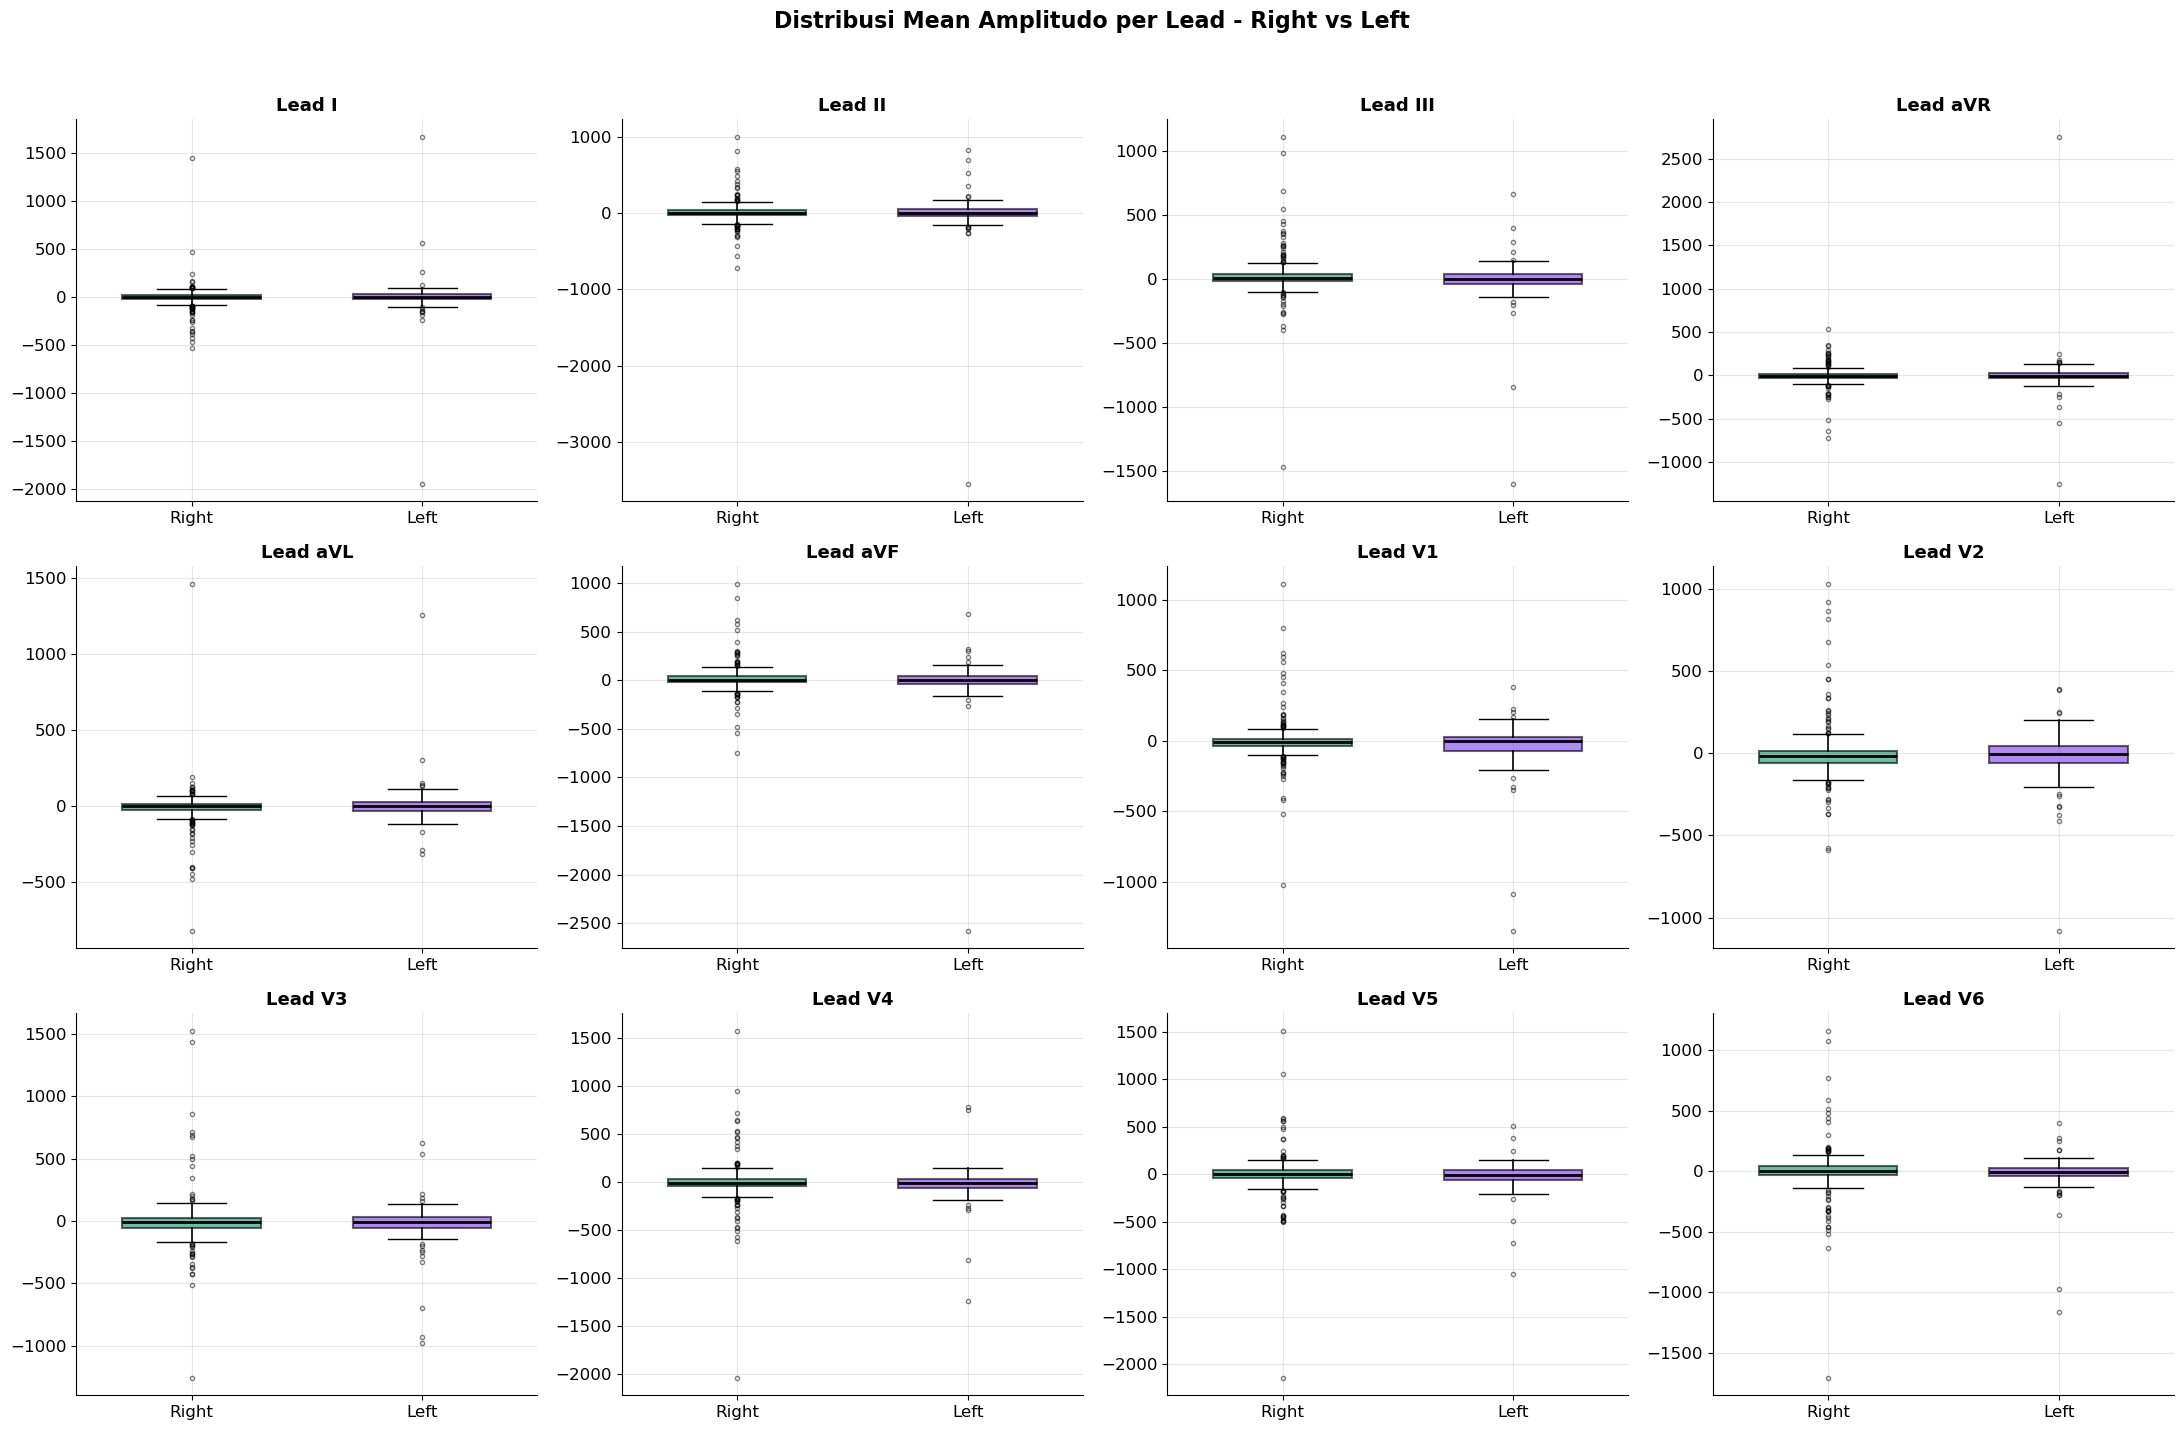

In [51]:
# Boxplot amplitudo per lead berdasarkan LeftRight
fig, axes = plt.subplots(3, 4, figsize=(22, 14))
fig.suptitle('Distribusi Mean Amplitudo per Lead - Right vs Left',
             fontsize=16, fontweight='bold', y=1.02)

for i, lead in enumerate(leads):
    row, col = i // 4, i % 4
    ax = axes[row, col]
    col_name = f'{lead}_mean'
    
    data_right = df_stats[df_stats['LeftRight'] == 'Right'][col_name]
    data_left = df_stats[df_stats['LeftRight'] == 'Left'][col_name]
    
    bp = ax.boxplot([data_right, data_left], labels=['Right', 'Left'],
                    patch_artist=True, widths=0.6,
                    boxprops=dict(linewidth=1.5),
                    medianprops=dict(linewidth=2, color='black'),
                    whiskerprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))
    bp['boxes'][0].set_facecolor('#059669')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#7C3AED')
    bp['boxes'][1].set_alpha(0.6)
    
    ax.set_title(f'Lead {lead}', fontsize=13, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'boxplot_rightleft_amplitude.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Analisis Frekuensi Sinyal EKG (FFT/Power Spectral Density)

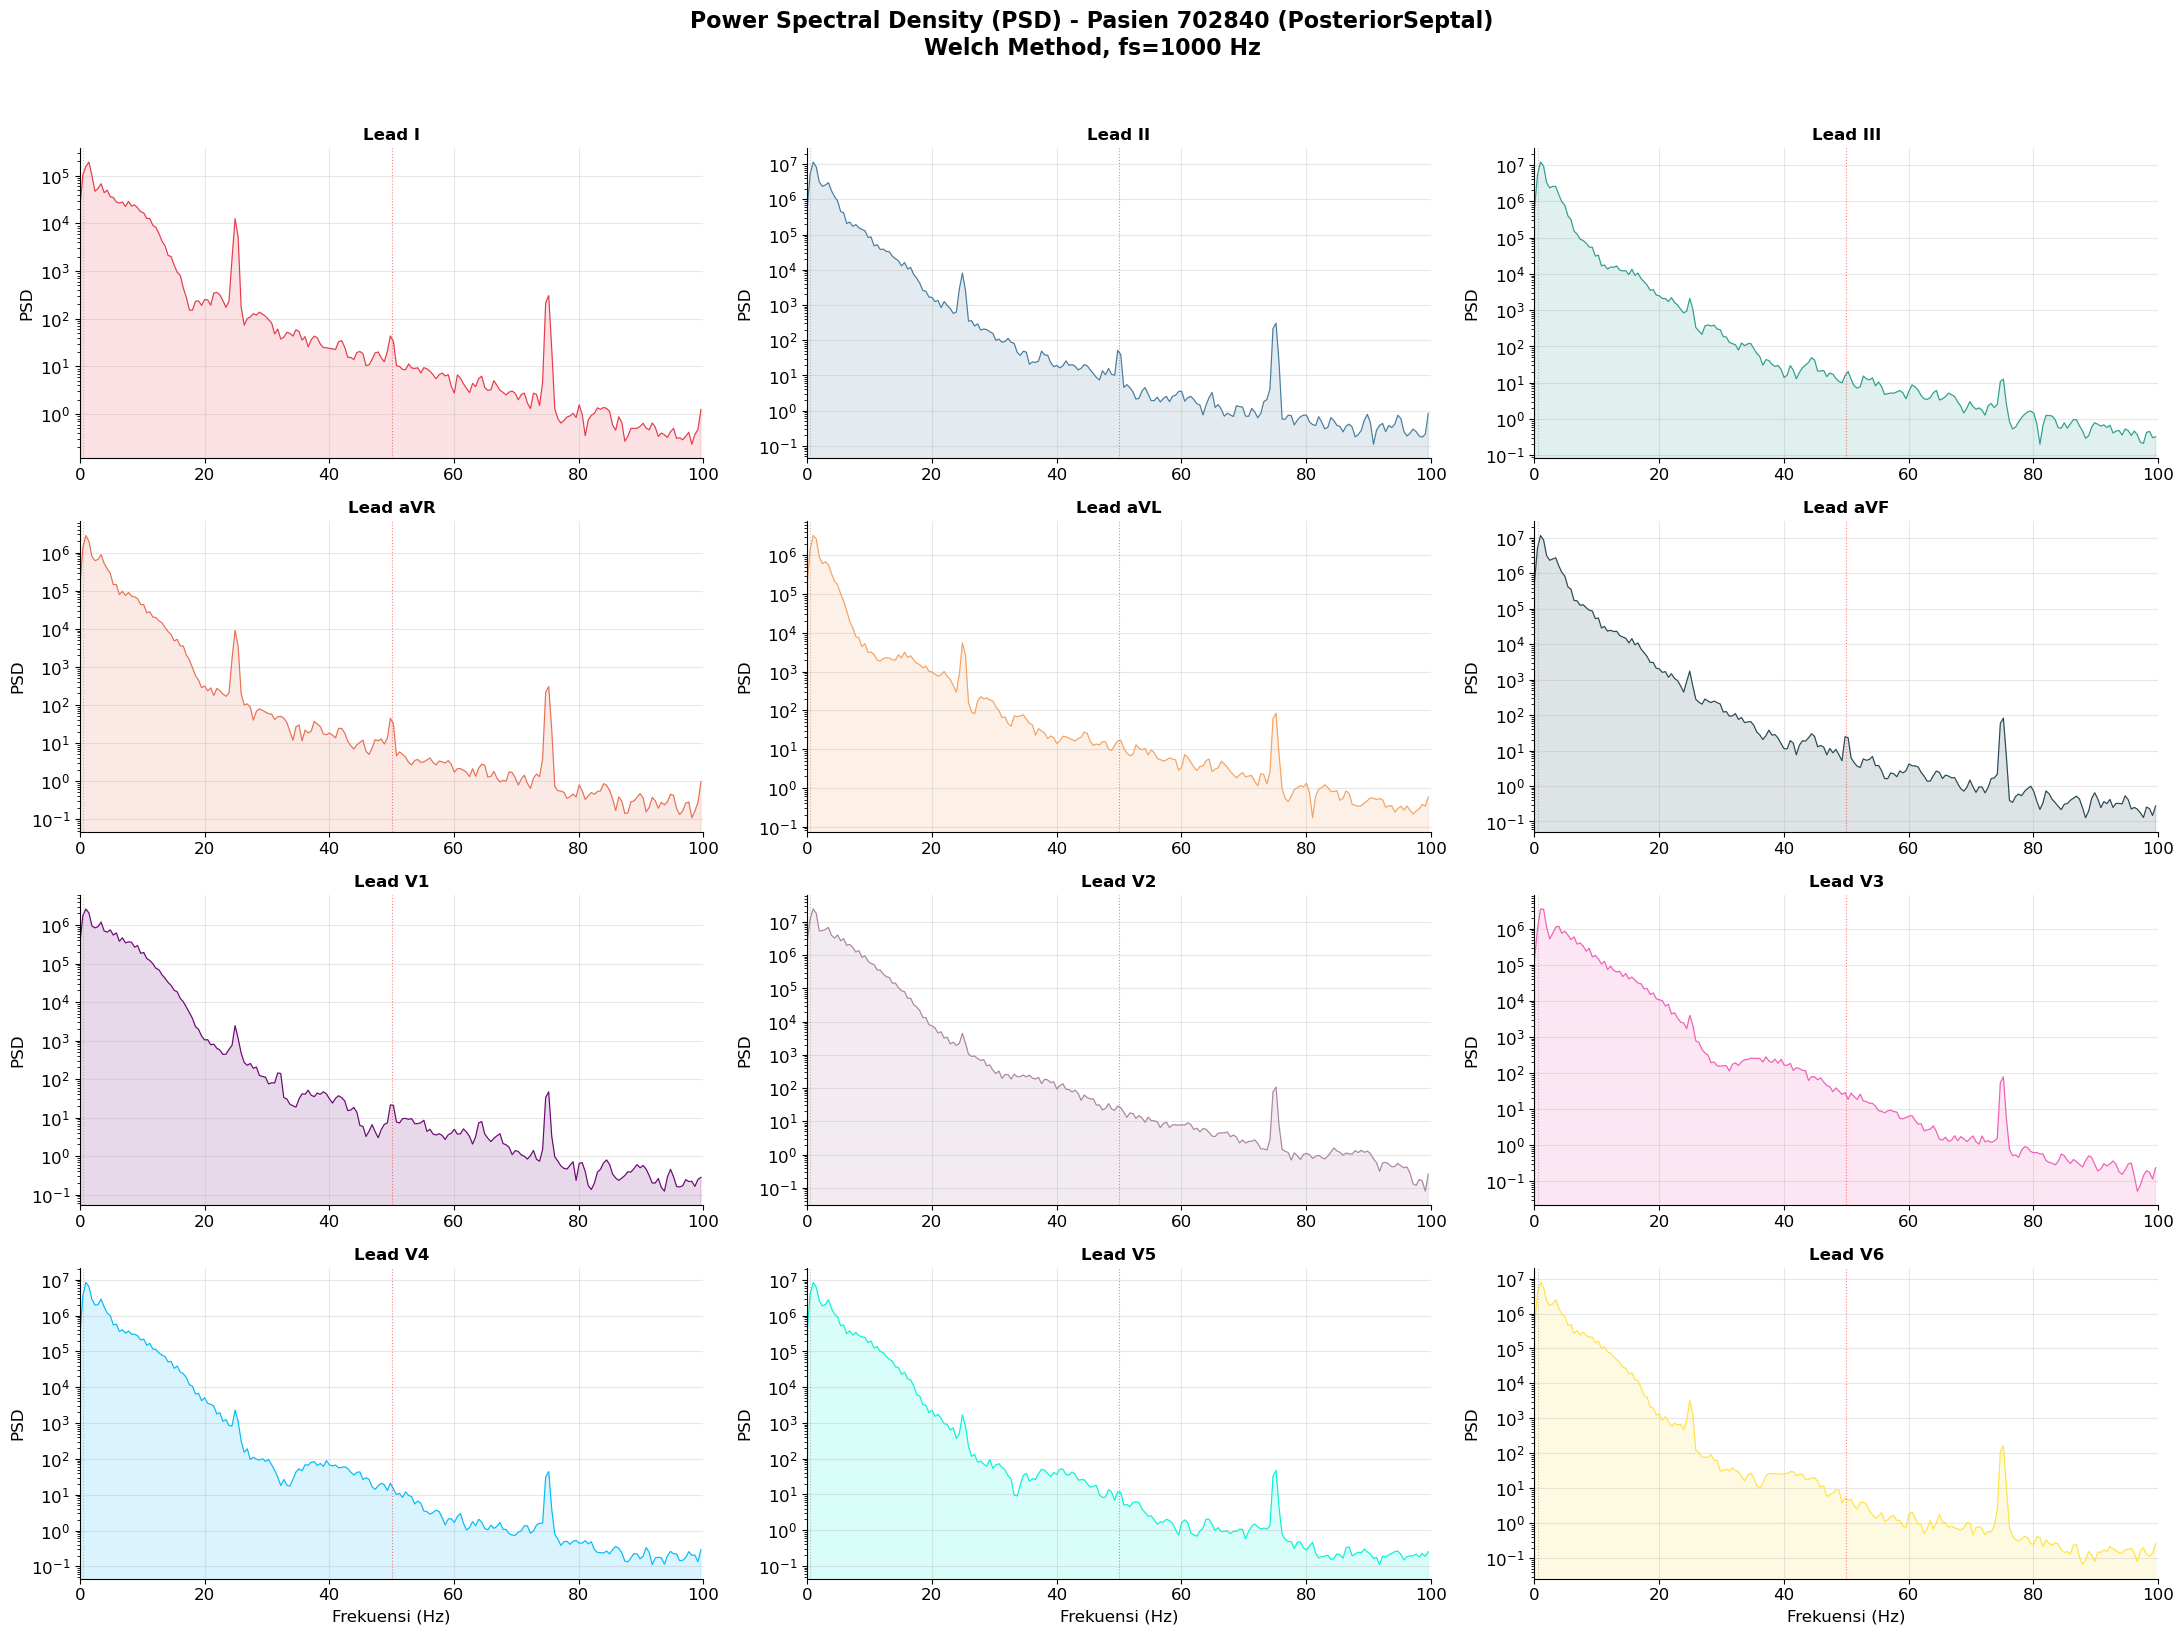

📊 Garis merah putus-putus = 50 Hz (noise PLN), Abu-abu = 0.5 Hz (baseline drift)


In [52]:
# PSD untuk satu sample pasien
pid_sample = sample_patients[0][0]
subloc_sample = sample_patients[0][1]
ecg_sample = load_ecg(pid_sample, RAW_ECG_DIR)

fig, axes = plt.subplots(4, 3, figsize=(22, 16))
fig.suptitle(f'Power Spectral Density (PSD) - Pasien {pid_sample} ({subloc_sample})\n'
             f'Welch Method, fs={SAMPLING_RATE} Hz',
             fontsize=16, fontweight='bold', y=1.02)

for i, lead in enumerate(leads):
    row, col = i // 3, i % 3
    ax = axes[row, col]
    
    freqs, psd = signal.welch(ecg_sample[lead].values, fs=SAMPLING_RATE, nperseg=2048)
    
    # Hanya tampilkan 0-100 Hz
    mask = freqs <= 100
    ax.semilogy(freqs[mask], psd[mask], color=LEAD_COLORS[lead], linewidth=0.8)
    ax.fill_between(freqs[mask], psd[mask], alpha=0.15, color=LEAD_COLORS[lead])
    ax.set_title(f'Lead {lead}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frekuensi (Hz)' if row == 3 else '')
    ax.set_ylabel('PSD')
    ax.set_xlim(0, 100)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Tandai frekuensi penting
    ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)
    ax.axvline(x=50, color='red', linestyle=':', alpha=0.5, linewidth=0.8)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'psd_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("📊 Garis merah putus-putus = 50 Hz (noise PLN), Abu-abu = 0.5 Hz (baseline drift)")

---
## 8. Discrete Wavelet Transform (DWT) untuk Denoising

In [53]:
# Import PyWavelets
try:
    import pywt
    print("✅ PyWavelets berhasil dimuat")
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'PyWavelets'])
    import pywt
    print("✅ PyWavelets berhasil diinstall dan dimuat")

print(f"📦 PyWavelets version: {pywt.__version__}")
print(f"📋 Available wavelets: {pywt.wavelist()[:20]}...")

✅ PyWavelets berhasil dimuat
📦 PyWavelets version: 1.7.0
📋 Available wavelets: ['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5']...


In [54]:
def sure_threshold(coeffs, sigma):
    """
    Menghitung Stein's Unbiased Risk Estimate (SURE) threshold dengan noise scaling.
    """
    n = len(coeffs)
    if n == 0 or sigma == 0:
        return 0.0
        
    # Skalakan koefisien agar varians noise ≈ 1
    norm_coeffs = coeffs / sigma
    a = np.sort(np.abs(norm_coeffs))**2
    
    c = np.linspace(n-1, 0, n)
    s = np.cumsum(a)
    risk = (n - 2 * np.arange(1, n+1) + s + c * a) / n
    
    best_idx = np.argmin(risk)
    # Kembalikan threshold ke skala asli
    return np.sqrt(a[best_idx]) * sigma

def baseline_wander_removal(signal_data, fs=1000, cutoff=0.5):
    """
    Menghilangkan baseline wander menggunakan Butterworth High-Pass Filter.
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    # Orde 4 Butterworth filter
    b, a = signal.butter(4, normal_cutoff, btype='high', analog=False)
    # Gunakan filtfilt agar tidak ada pergeseran fasa (zero-phase filtering)
    filtered_signal = signal.filtfilt(b, a, signal_data)
    return filtered_signal

def dwt_denoise(signal_data, wavelet='coif5', level=5, threshold_mode='soft'):
    """
    Denoising sinyal EKG: High-Pass Filter (Baseline Wander) + DWT (High-freq noise).
    
    Parameters:
    -----------
    signal_data : array-like
        Sinyal input (1D)
    wavelet : str
        Tipe wavelet (default: 'coif5', cocok untuk EKG)
    level : int
        Level dekomposisi (default: 5, agar mencakup noise 25 Hz)
    threshold_mode : str
        Mode thresholding ('soft' atau 'hard')
    
    Returns:
    --------
    denoised : array
        Sinyal yang telah di-denoise
    coeffs : list
        Koefisien wavelet
    """
    # 1. Hilangkan Baseline Wander (Low-frequency noise) terlebih dahulu
    signal_no_baseline = baseline_wander_removal(signal_data, fs=1000, cutoff=0.5)

    # 2. Dekomposisi wavelet untuk menghilangkan high-frequency noise
    coeffs = pywt.wavedec(signal_no_baseline, wavelet, level=level)
    
    # Terapkan SURE thresholding pada koefisien detail (bukan approximation)
    coeffs_thresholded = [coeffs[0]]  # Keep approximation coefficients
    for i in range(1, len(coeffs)):
        # Estimasi standar deviasi noise (sigma) SECARA SPESIFIK untuk setiap level
        sigma = np.median(np.abs(coeffs[i])) / 0.6745
        
        # Hitung SURE threshold dengan scaling sigma
        threshold = sure_threshold(coeffs[i], sigma)
        coeffs_thresholded.append(
            pywt.threshold(coeffs[i], threshold, mode=threshold_mode)
        )
    
    # Rekonstruksi sinyal
    denoised = pywt.waverec(coeffs_thresholded, wavelet)
    
    # Pastikan panjang sama
    denoised = denoised[:len(signal_data)]
    
    return denoised, coeffs

print("✅ Fungsi DWT denoising siap digunakan")

✅ Fungsi DWT denoising siap digunakan


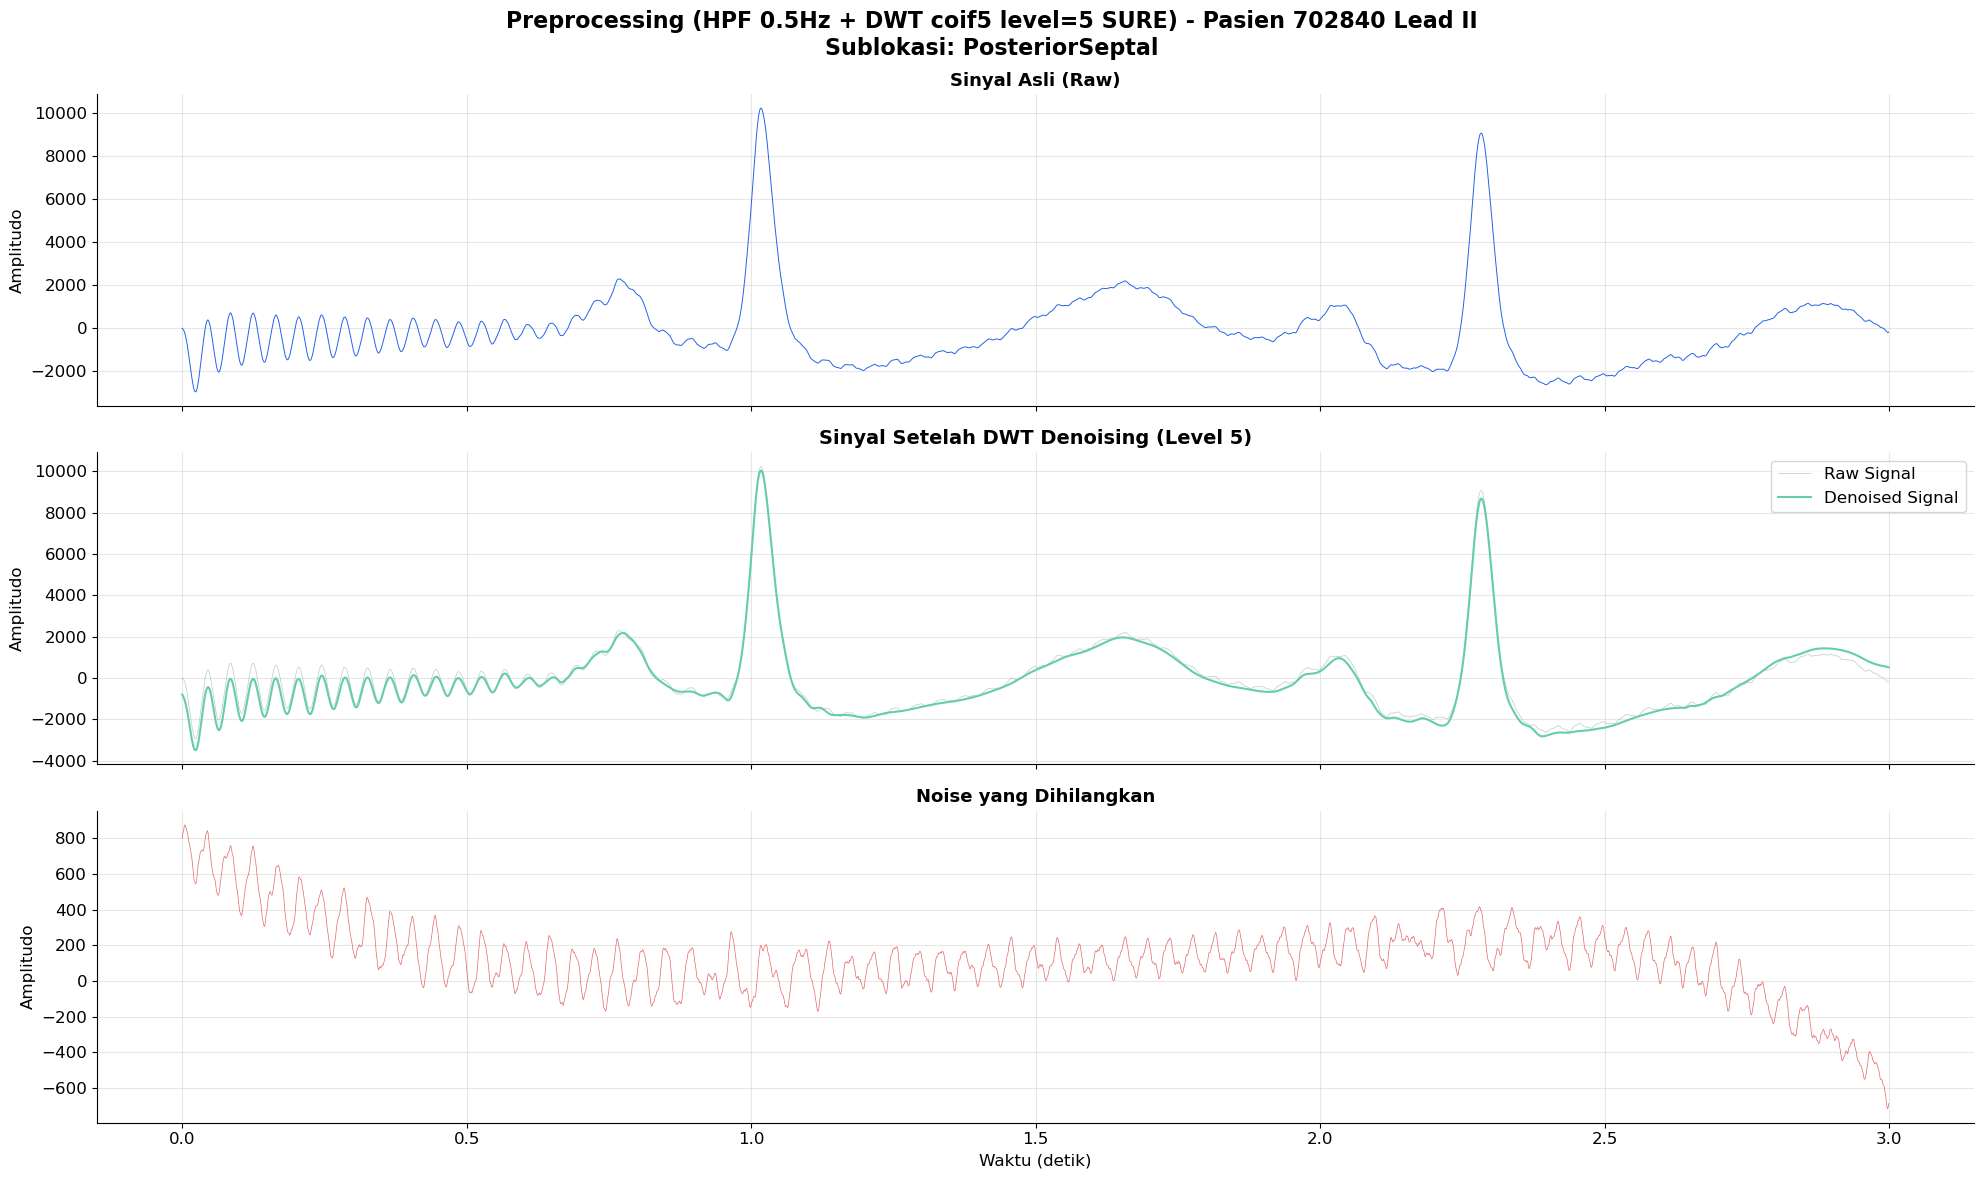


📊 Statistik Denoising:
   SNR estimasi: 13.64 dB
   Noise RMS: 931.11
   Signal RMS (raw): 4477.43
   Signal RMS (denoised): 4286.70


In [55]:
# Demonstrasi DWT denoising pada satu pasien
pid_demo = sample_patients[0][0]
subloc_demo = sample_patients[0][1]
ecg_demo = load_ecg(pid_demo, RAW_ECG_DIR)

# Denoise Lead II sebagai contoh
lead_demo = 'II'
raw_signal = ecg_demo[lead_demo].values
denoised_signal, coeffs = dwt_denoise(raw_signal, wavelet='coif5', level=5)
noise_removed = raw_signal - denoised_signal

# Visualisasi
fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)
fig.suptitle(f'Preprocessing (HPF 0.5Hz + DWT coif5 level=5 SURE) - Pasien {pid_demo} Lead {lead_demo}\n'
             f'Sublokasi: {subloc_demo}', fontsize=16, fontweight='bold')

duration_plot = 3  # detik
end_plot = min(duration_plot * SAMPLING_RATE, len(raw_signal))
time_plot = np.arange(end_plot) / SAMPLING_RATE

axes[0].plot(time_plot, raw_signal[:end_plot], color='#2563EB', linewidth=0.7)
axes[0].set_title('Sinyal Asli (Raw)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amplitudo')
axes[0].spines[['top', 'right']].set_visible(False)

# Plot Sinyal Denoised (dengan bayangan sinyal asli di belakangnya agar terlihat perbedaannya)
axes[1].plot(time_plot, raw_signal[:end_plot], color='#94A3B8', linewidth=0.5, alpha=0.6, label='Raw Signal')
axes[1].plot(time_plot, denoised_signal[:end_plot], color='mediumaquamarine', linewidth=1.5, label='Denoised Signal')
axes[1].set_title(f'Sinyal Setelah DWT Denoising (Level 5)', fontweight='bold')
axes[1].set_ylabel('Amplitudo')
axes[1].legend(loc='upper right')
axes[1].spines[['top', 'right']].set_visible(False)

axes[2].plot(time_plot, noise_removed[:end_plot], color='#DC2626', linewidth=0.5, alpha=0.7)
axes[2].set_title('Noise yang Dihilangkan', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Amplitudo')
axes[2].set_xlabel('Waktu (detik)')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'dwt_denoising_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

# SNR improvement
snr_before = 10 * np.log10(np.var(raw_signal) / np.var(noise_removed))
print(f"\n📊 Statistik Denoising:")
print(f"   SNR estimasi: {snr_before:.2f} dB")
print(f"   Noise RMS: {np.sqrt(np.mean(noise_removed**2)):.2f}")
print(f"   Signal RMS (raw): {np.sqrt(np.mean(raw_signal**2)):.2f}")
print(f"   Signal RMS (denoised): {np.sqrt(np.mean(denoised_signal**2)):.2f}")

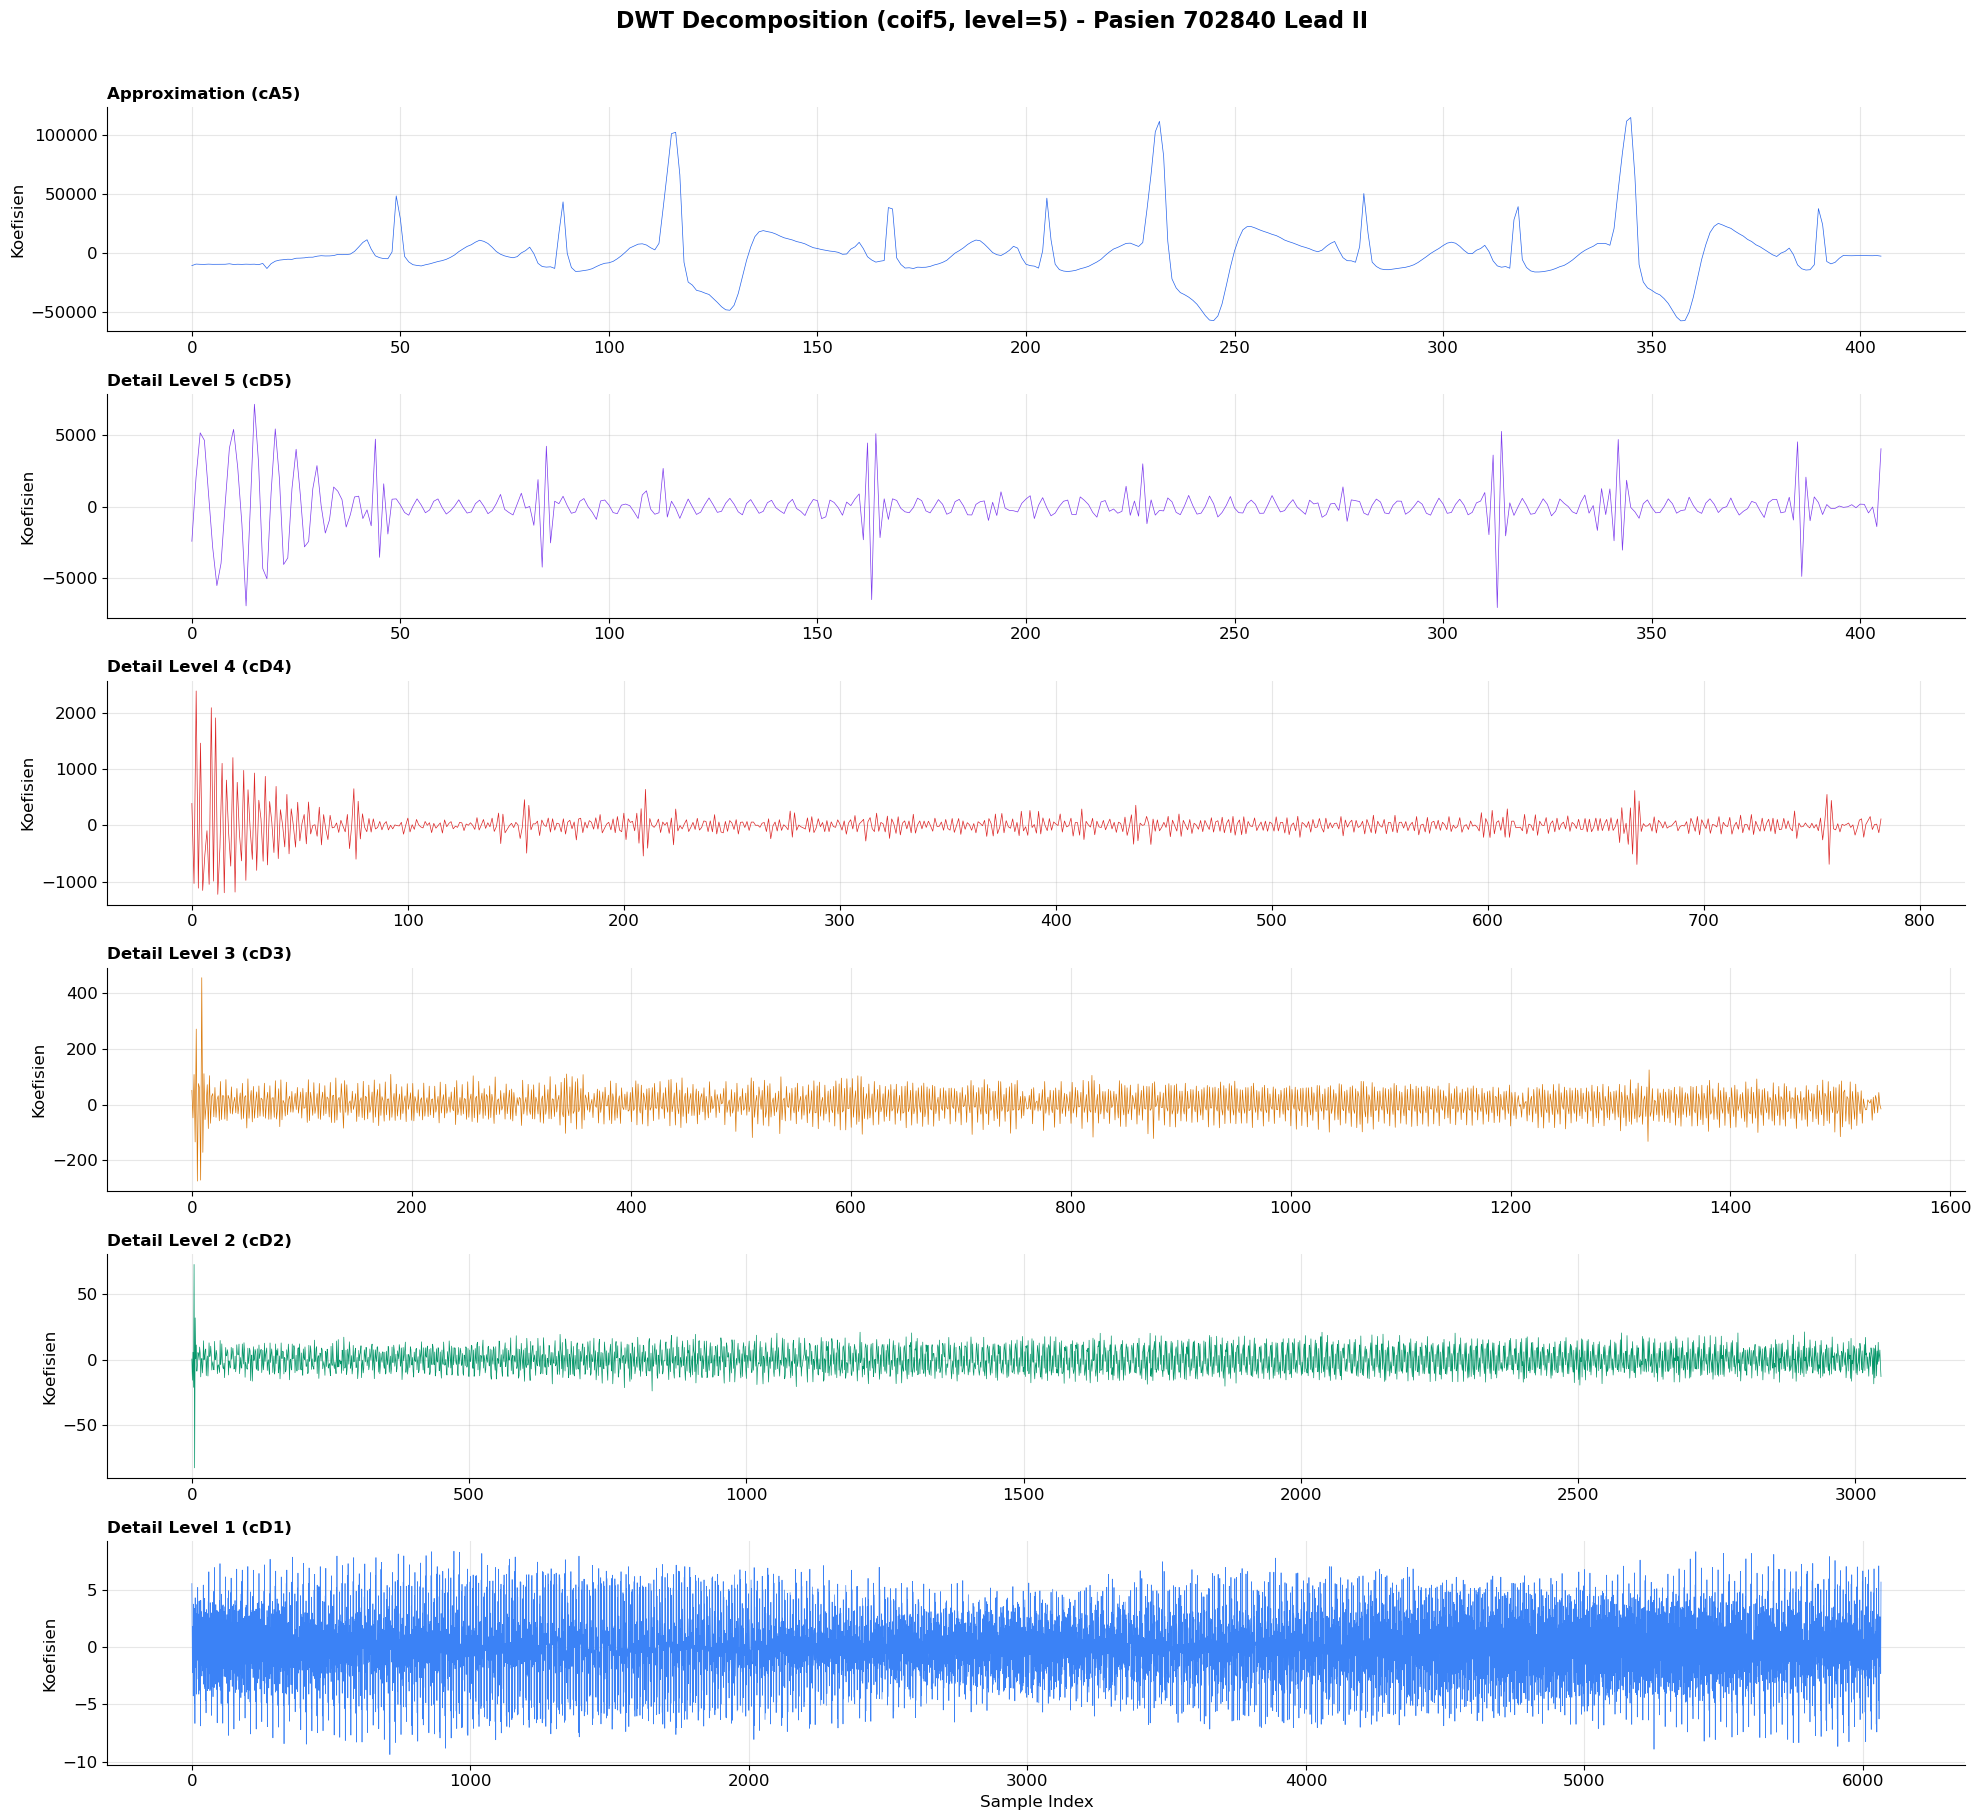

In [56]:
# Visualisasi Wavelet Decomposition
fig, axes = plt.subplots(len(coeffs), 1, figsize=(20, 3*len(coeffs)))
fig.suptitle(f'DWT Decomposition (coif5, level=5) - Pasien {pid_demo} Lead {lead_demo}',
             fontsize=16, fontweight='bold', y=1.01)

labels = ['Approximation (cA5)'] + [f'Detail Level {i} (cD{i})' for i in range(5, 0, -1)]
colors_dwt = ['#2563EB', '#7C3AED', '#DC2626', '#D97706', '#059669', '#3B82F6']

for i, (coeff, label, color) in enumerate(zip(coeffs, labels, colors_dwt)):
    axes[i].plot(coeff, color=color, linewidth=0.5)
    axes[i].set_title(label, fontsize=12, fontweight='bold', loc='left')
    axes[i].set_ylabel('Koefisien')
    axes[i].spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Sample Index')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'dwt_decomposition.png'), dpi=150, bbox_inches='tight')
plt.show()

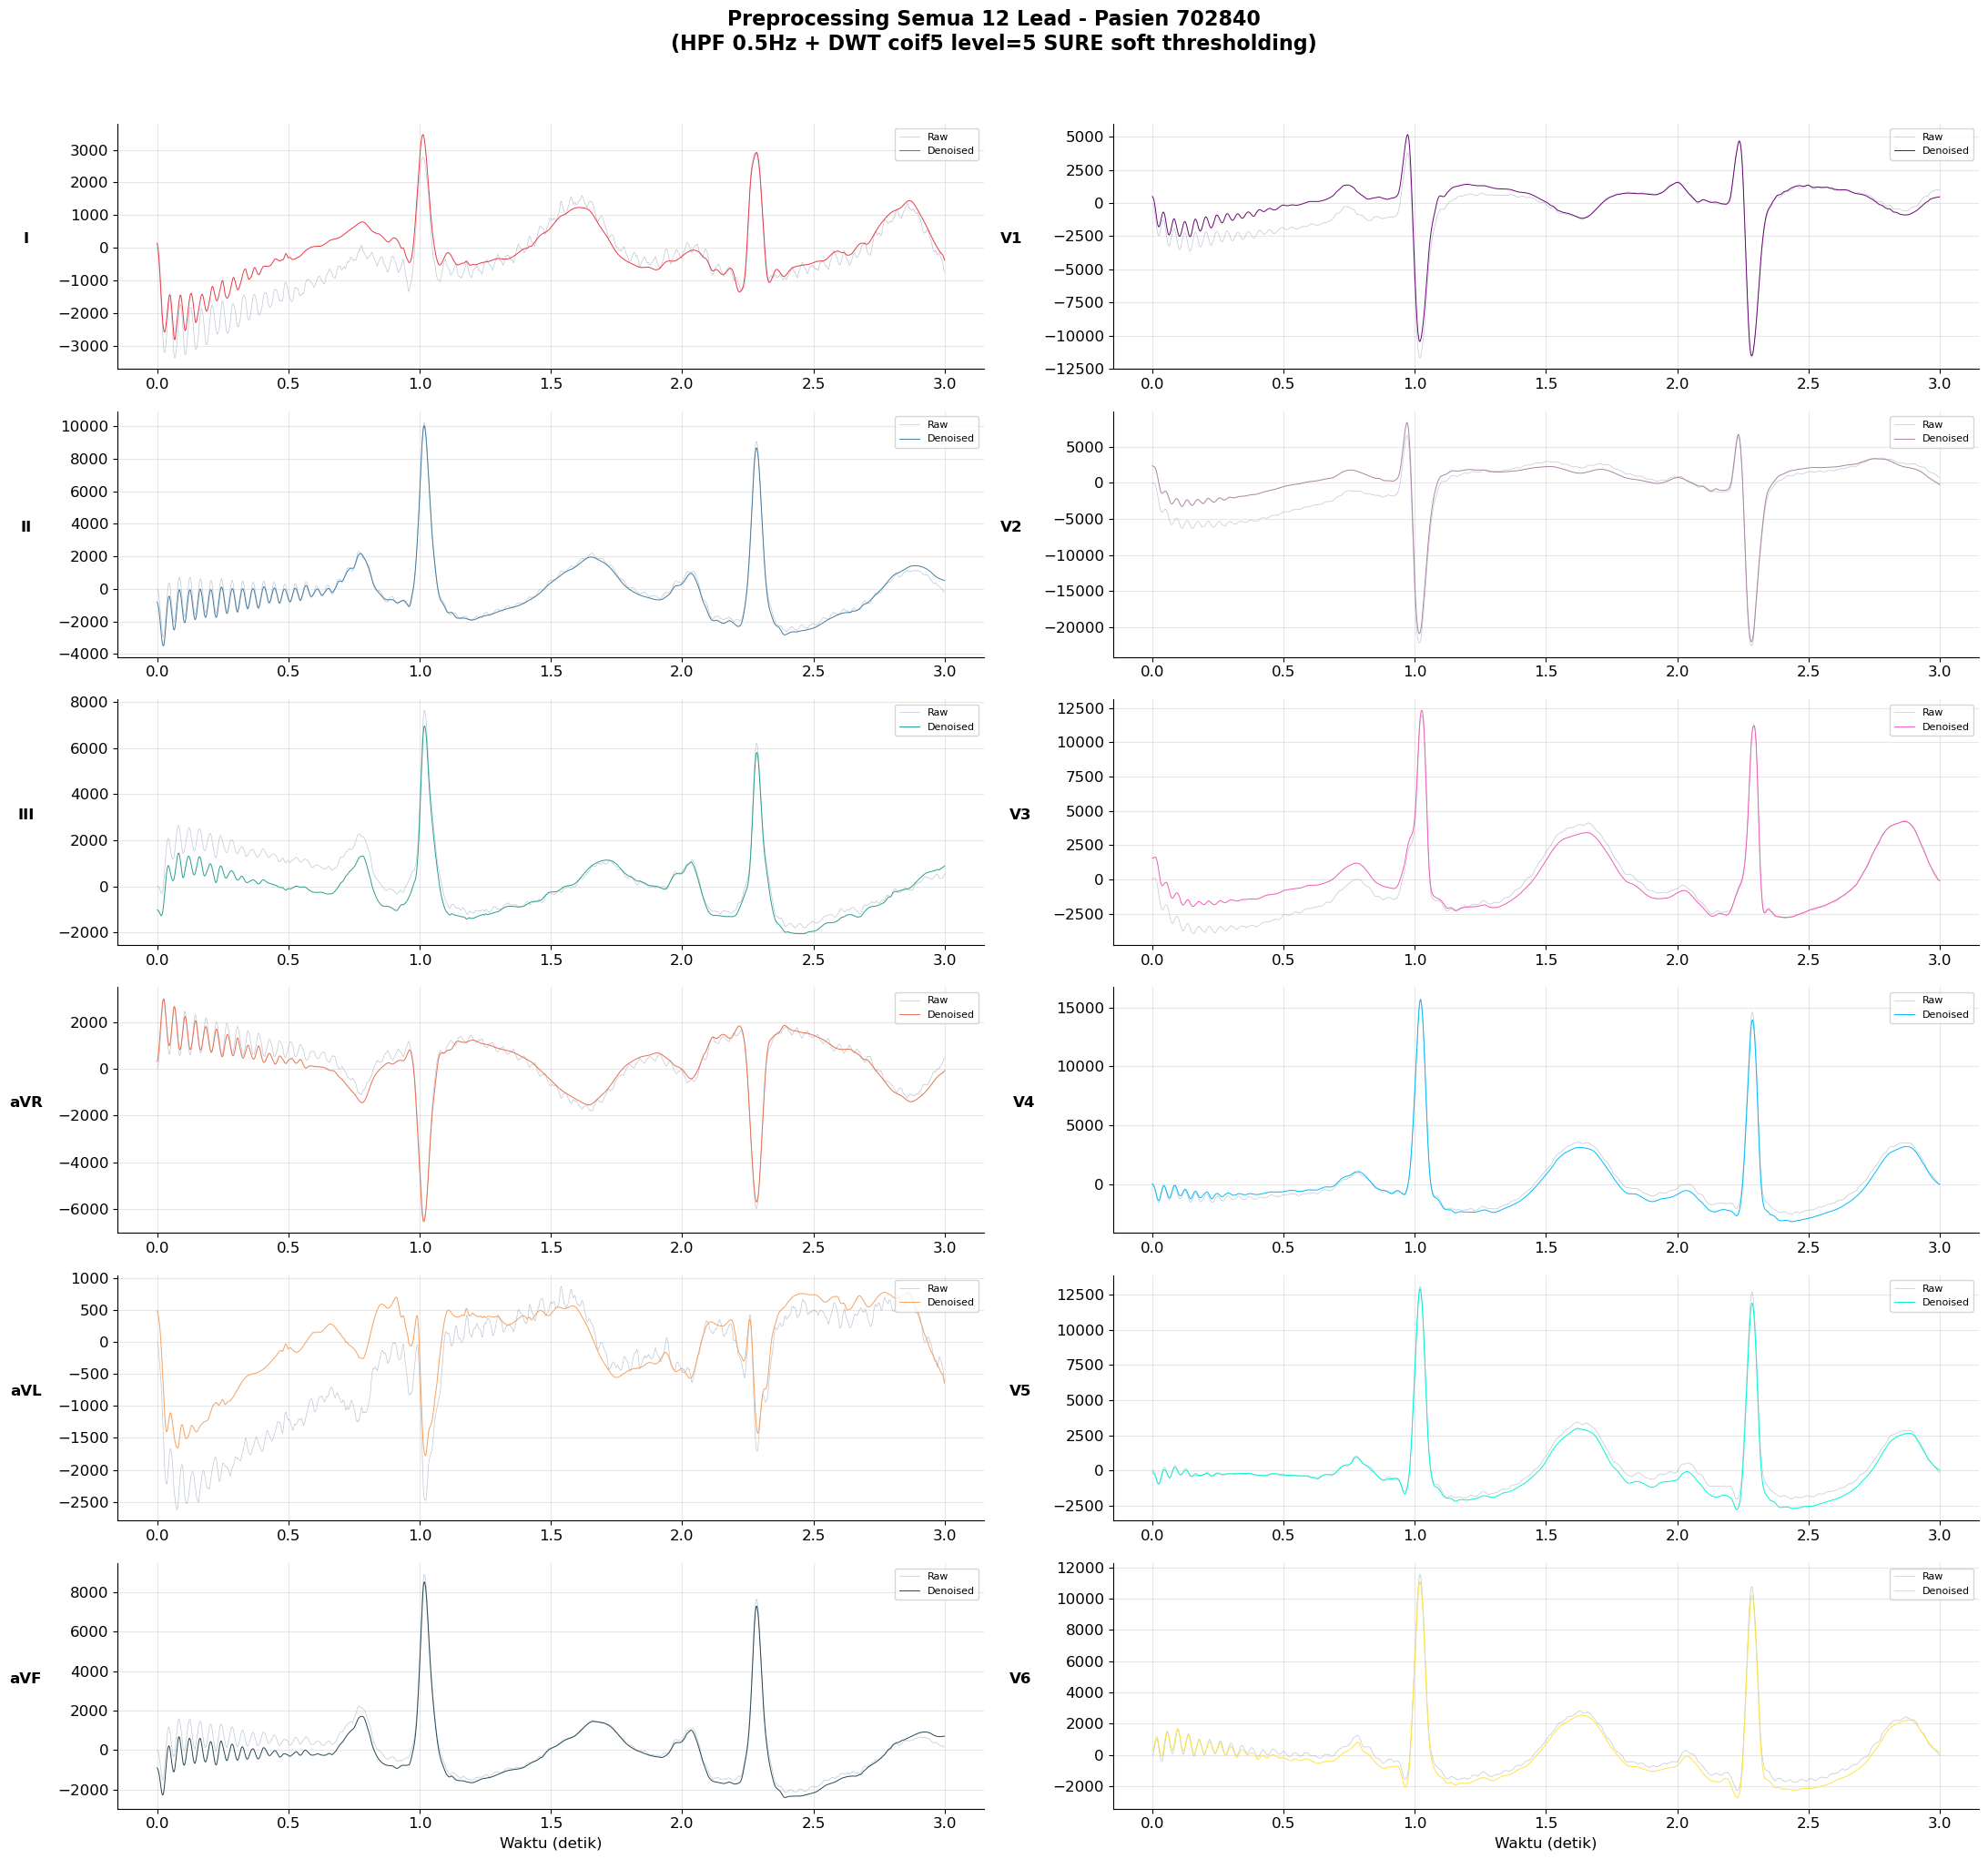

In [57]:
# Demonstrasi DWT denoising pada semua 12 lead
fig, axes = plt.subplots(6, 2, figsize=(22, 20))
fig.suptitle(f'Preprocessing Semua 12 Lead - Pasien {pid_demo}\n'
             f'(HPF 0.5Hz + DWT coif5 level=5 SURE soft thresholding)',
             fontsize=16, fontweight='bold', y=1.02)

lead_positions = [
    ('I', 0, 0), ('V1', 0, 1),
    ('II', 1, 0), ('V2', 1, 1),
    ('III', 2, 0), ('V3', 2, 1),
    ('aVR', 3, 0), ('V4', 3, 1),
    ('aVL', 4, 0), ('V5', 4, 1),
    ('aVF', 5, 0), ('V6', 5, 1),
]

duration_all = 3
end_all = min(duration_all * SAMPLING_RATE, len(ecg_demo))
time_all = np.arange(end_all) / SAMPLING_RATE

for lead_name, row, col in lead_positions:
    ax = axes[row, col]
    raw_sig = ecg_demo[lead_name].values
    den_sig, _ = dwt_denoise(raw_sig, level=5)
    
    ax.plot(time_all, raw_sig[:end_all], color='#94A3B8', linewidth=0.5, alpha=0.6, label='Raw')
    ax.plot(time_all, den_sig[:end_all], color=LEAD_COLORS[lead_name], linewidth=0.7, label='Denoised')
    ax.set_ylabel(lead_name, fontsize=12, fontweight='bold', rotation=0, labelpad=25)
    ax.legend(loc='upper right', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    
    if row == 5:
        ax.set_xlabel('Waktu (detik)')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'dwt_all_leads_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. DWT Denoising Seluruh Dataset & Penyimpanan

In [58]:
# Proses DWT denoising untuk seluruh dataset
print("=" * 70)
print("⏳ PROSES DWT DENOISING SELURUH DATASET")
print("=" * 70)

DWT_OUTPUT_DIR = OUTPUT_DIR / 'dwt_denoised'
DWT_OUTPUT_DIR.mkdir(exist_ok=True)

total = len(df_diagnosis)
errors = []

for idx, row in df_diagnosis.iterrows():
    hid = row['HospitalID']
    try:
        ecg_raw = pd.read_csv(RAW_ECG_DIR / f"{hid}.csv")
        ecg_denoised = pd.DataFrame()
        
        for lead in leads:
            denoised, _ = dwt_denoise(ecg_raw[lead].values, wavelet='coif5', level=5)
            ecg_denoised[lead] = denoised
        
        ecg_denoised.to_csv(DWT_OUTPUT_DIR / f"{hid}.csv", index=False)
        
        if (idx + 1) % 50 == 0 or idx == total - 1:
            print(f"   ✅ Processed {idx + 1}/{total} ({(idx+1)/total*100:.0f}%)")
    except Exception as e:
        errors.append((hid, str(e)))
        print(f"   ❌ Error {hid}: {e}")

print(f"\n{'='*70}")
print(f"✅ DWT Denoising selesai: {total - len(errors)}/{total} berhasil")
if errors:
    print(f"❌ Gagal: {len(errors)} file")
    for hid, err in errors:
        print(f"   • {hid}: {err}")
print(f"📁 Output: {DWT_OUTPUT_DIR}")

⏳ PROSES DWT DENOISING SELURUH DATASET
   ✅ Processed 50/334 (15%)
   ✅ Processed 100/334 (30%)
   ✅ Processed 150/334 (45%)
   ✅ Processed 200/334 (60%)
   ✅ Processed 250/334 (75%)
   ✅ Processed 300/334 (90%)
   ✅ Processed 334/334 (100%)

✅ DWT Denoising selesai: 334/334 berhasil
📁 Output: preprocessed_data/dwt_denoised


---
## 10. Data Splitting (80/20 Stratified)

In [59]:
from sklearn.model_selection import train_test_split

# Membuat label untuk stratifikasi
# Menggunakan kombinasi LeftRight sebagai label utama untuk lokalisasi
# (Sublocation memiliki missing values, jadi stratify berdasarkan LeftRight)

print("=" * 70)
print("✂️ DATA SPLITTING - 80% Training / 20% Testing (Stratified)")
print("=" * 70)

# Label yang akan digunakan
# Untuk lokalisasi, kita bisa menggunakan LeftRight atau Sublocation
# Karena Sublocation ada missing, kita pakai LeftRight untuk stratify

X = df_diagnosis['HospitalID'].values
y = df_diagnosis['LeftRight'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Hasil Splitting:")
print(f"   Total Data    : {len(X)} pasien")
print(f"   Training (80%): {len(X_train)} pasien")
print(f"   Testing  (20%): {len(X_test)} pasien")

print(f"\n📊 Distribusi Label - Training Set:")
train_counts = pd.Series(y_train).value_counts()
for label, count in train_counts.items():
    print(f"   {label}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\n📊 Distribusi Label - Testing Set:")
test_counts = pd.Series(y_test).value_counts()
for label, count in test_counts.items():
    print(f"   {label}: {count} ({count/len(y_test)*100:.1f}%)")

✂️ DATA SPLITTING - 80% Training / 20% Testing (Stratified)

📊 Hasil Splitting:
   Total Data    : 334 pasien
   Training (80%): 267 pasien
   Testing  (20%): 67 pasien

📊 Distribusi Label - Training Set:
   Right: 205 (76.8%)
   Left: 62 (23.2%)

📊 Distribusi Label - Testing Set:
   Right: 52 (77.6%)
   Left: 15 (22.4%)


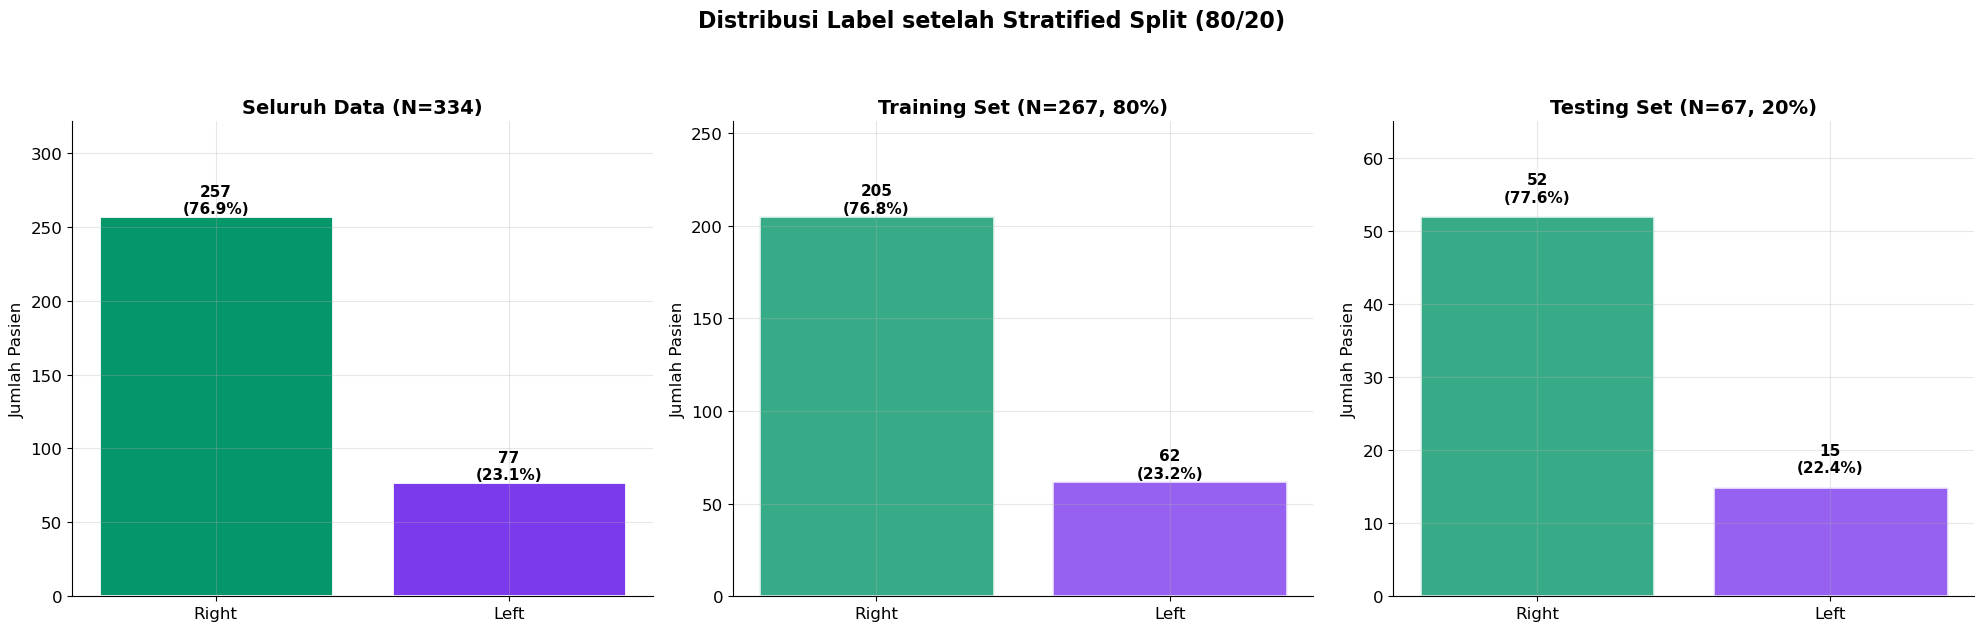

In [60]:
# Visualisasi distribusi split
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Overall
ax = axes[0]
overall_counts = pd.Series(y).value_counts()
ax.bar(overall_counts.index, overall_counts.values, color=['#059669', '#7C3AED'],
       edgecolor='white', linewidth=2)
for i, (label, count) in enumerate(overall_counts.items()):
    ax.text(i, count + 2, f'{count}\n({count/len(y)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title(f'Seluruh Data (N={len(y)})', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Pasien')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(overall_counts.values) * 1.25)

# Training
ax = axes[1]
ax.bar(train_counts.index, train_counts.values, color=['#059669', '#7C3AED'],
       edgecolor='white', linewidth=2, alpha=0.8)
for i, (label, count) in enumerate(train_counts.items()):
    ax.text(i, count + 2, f'{count}\n({count/len(y_train)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title(f'Training Set (N={len(y_train)}, 80%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Pasien')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(train_counts.values) * 1.25)

# Testing
ax = axes[2]
ax.bar(test_counts.index, test_counts.values, color=['#059669', '#7C3AED'],
       edgecolor='white', linewidth=2, alpha=0.8)
for i, (label, count) in enumerate(test_counts.items()):
    ax.text(i, count + 2, f'{count}\n({count/len(y_test)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title(f'Testing Set (N={len(y_test)}, 20%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Pasien')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(test_counts.values) * 1.25)

plt.suptitle('Distribusi Label setelah Stratified Split (80/20)',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'data_splitting.png'), dpi=150, bbox_inches='tight')
plt.show()

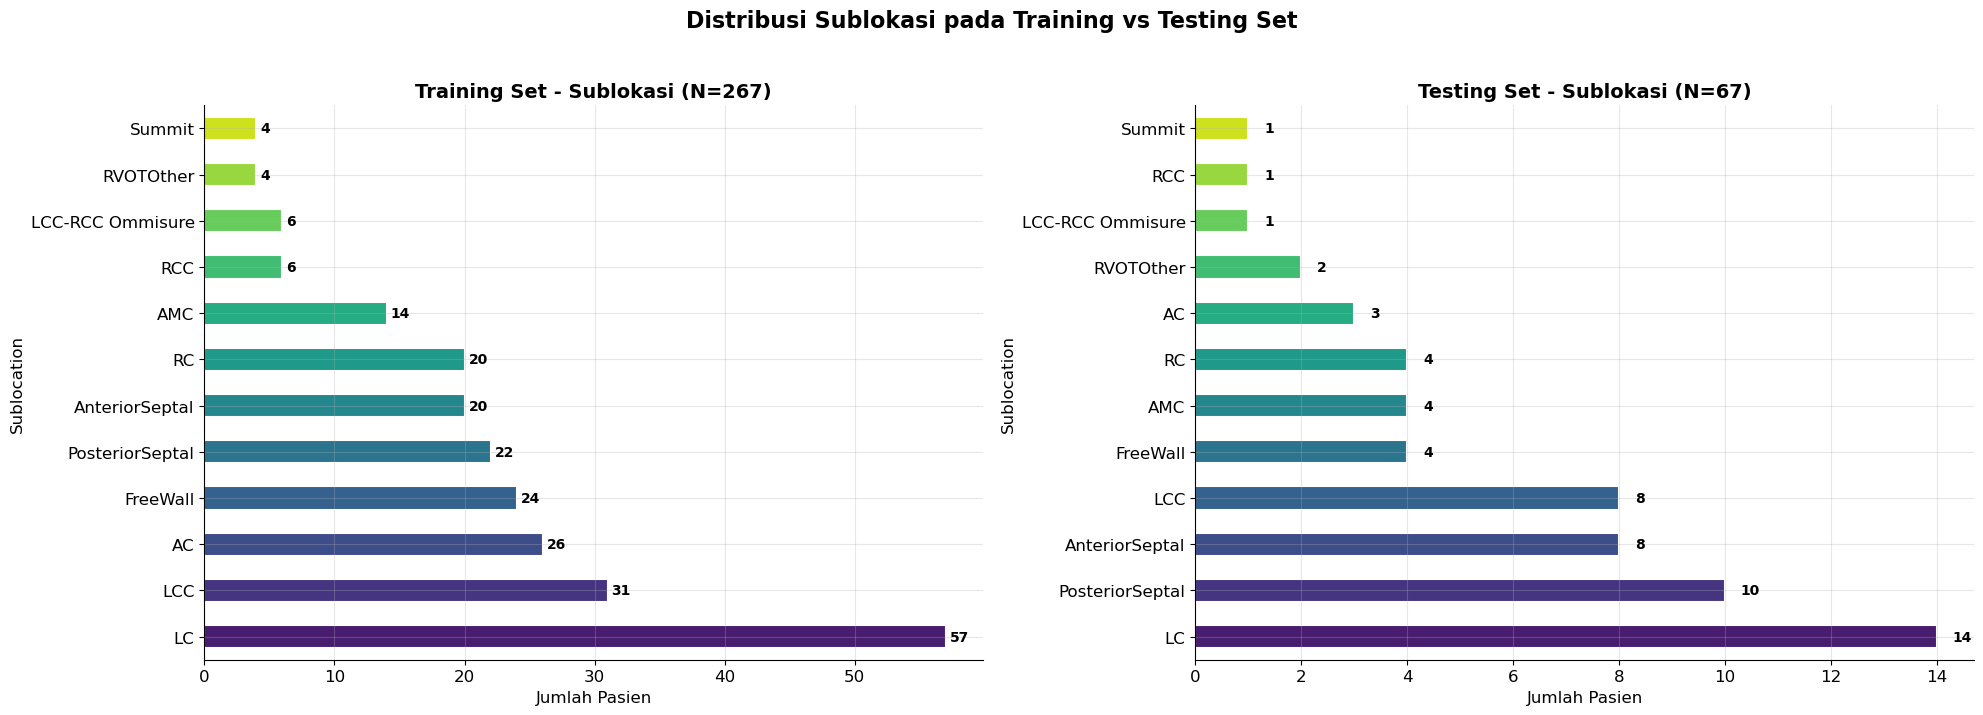

In [61]:
# Juga cek distribusi Sublocation di train vs test
df_train = df_diagnosis[df_diagnosis['HospitalID'].isin(X_train)]
df_test = df_diagnosis[df_diagnosis['HospitalID'].isin(X_test)]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Training sublocation
ax = axes[0]
sub_train = df_train['Sublocation'].value_counts()
sub_train.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(sub_train)),
               edgecolor='white', linewidth=1.5)
for i, (val, count) in enumerate(sub_train.items()):
    ax.text(count + 0.3, i, f'{count}', va='center', fontweight='bold', fontsize=10)
ax.set_title(f'Training Set - Sublokasi (N={len(df_train)})', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Pasien')
ax.spines[['top', 'right']].set_visible(False)

# Testing sublocation
ax = axes[1]
sub_test = df_test['Sublocation'].value_counts()
sub_test.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(sub_test)),
              edgecolor='white', linewidth=1.5)
for i, (val, count) in enumerate(sub_test.items()):
    ax.text(count + 0.3, i, f'{count}', va='center', fontweight='bold', fontsize=10)
ax.set_title(f'Testing Set - Sublokasi (N={len(df_test)})', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Pasien')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribusi Sublokasi pada Training vs Testing Set',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'split_sublocation.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Menyimpan Metadata Split & Data Terproses

In [62]:
# Simpan metadata split
split_metadata = pd.DataFrame({
    'HospitalID': np.concatenate([X_train, X_test]),
    'Split': ['train'] * len(X_train) + ['test'] * len(X_test),
})

# Merge dengan diagnosis
split_full = split_metadata.merge(df_diagnosis, on='HospitalID', how='left')
split_full.to_csv(OUTPUT_DIR / 'split_metadata.csv', index=False)

print("=" * 70)
print("💾 DATA TERSIMPAN")
print("=" * 70)
print(f"\n📁 Output Directory: {OUTPUT_DIR.resolve()}")
print(f"\n📄 File yang disimpan:")
print(f"   • split_metadata.csv  : Metadata split train/test ({len(split_full)} rows)")
print(f"   • dwt_denoised/       : Sinyal EKG terdenoise ({len(list(DWT_OUTPUT_DIR.glob('*.csv')))} files)")

# Simpan juga list train/test IDs
np.save(OUTPUT_DIR / 'train_ids.npy', X_train)
np.save(OUTPUT_DIR / 'test_ids.npy', X_test)
print(f"   • train_ids.npy       : {len(X_train)} training IDs")
print(f"   • test_ids.npy        : {len(X_test)} testing IDs")

# Simpan statistik
df_stats.to_csv(OUTPUT_DIR / 'ecg_statistics.csv', index=False)
print(f"   • ecg_statistics.csv  : Statistik sinyal EKG ({len(df_stats)} rows)")

💾 DATA TERSIMPAN

📁 Output Directory: /Users/daniandra/Downloads/TA GUWEH/PVC-Localization-with-CNN-Transformer/preprocessed_data

📄 File yang disimpan:
   • split_metadata.csv  : Metadata split train/test (334 rows)
   • dwt_denoised/       : Sinyal EKG terdenoise (334 files)
   • train_ids.npy       : 267 training IDs
   • test_ids.npy        : 67 testing IDs
   • ecg_statistics.csv  : Statistik sinyal EKG (334 rows)


In [63]:
# Verifikasi data tersimpan
print("\n" + "=" * 70)
print("✅ VERIFIKASI DATA")
print("=" * 70)

# Load balik
split_check = pd.read_csv(OUTPUT_DIR / 'split_metadata.csv')
train_ids_check = np.load(OUTPUT_DIR / 'train_ids.npy', allow_pickle=True)
test_ids_check = np.load(OUTPUT_DIR / 'test_ids.npy', allow_pickle=True)

print(f"\n📊 Split Metadata:")
print(f"   Total: {len(split_check)}")
print(f"   Train: {len(split_check[split_check['Split']=='train'])}")
print(f"   Test : {len(split_check[split_check['Split']=='test'])}")
print(f"\n📊 ID Arrays:")
print(f"   Train IDs: {len(train_ids_check)}")
print(f"   Test IDs : {len(test_ids_check)}")

# Cek DWT files
dwt_files = list(DWT_OUTPUT_DIR.glob('*.csv'))
print(f"\n📊 DWT Denoised Files: {len(dwt_files)}")

# Sample: load satu file DWT dan bandingkan
sample_dwt = pd.read_csv(dwt_files[0])
sample_raw = pd.read_csv(RAW_ECG_DIR / dwt_files[0].name)
print(f"\n📊 Sample DWT file ({dwt_files[0].name}):")
print(f"   Shape: {sample_dwt.shape}")
print(f"   Columns: {sample_dwt.columns.tolist()}")
print(f"   Match raw shape: {sample_dwt.shape == sample_raw.shape}")


✅ VERIFIKASI DATA

📊 Split Metadata:
   Total: 334
   Train: 267
   Test : 67

📊 ID Arrays:
   Train IDs: 267
   Test IDs : 67

📊 DWT Denoised Files: 334

📊 Sample DWT file (1012874.csv):
   Shape: (92790, 12)
   Columns: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
   Match raw shape: True


---
## 12. Ringkasan EDA & Preprocessing

In [64]:
print("=" * 70)
print("📋 RINGKASAN EDA & PREPROCESSING")
print("=" * 70)

print(f"""
🔬 DATASET OVERVIEW:
   • Total Pasien       : {len(df_diagnosis)}
   • Tipe Aritmia       : PVC ({(df_diagnosis['Type']=='PVC').sum()}), VT ({(df_diagnosis['Type']=='VT').sum()})
   • Lateralitas        : Right ({(df_diagnosis['LeftRight']=='Right').sum()}), Left ({(df_diagnosis['LeftRight']=='Left').sum()})
   • Sublokasi          : {df_diagnosis['Sublocation'].nunique()} kategori (40 missing)
   • Gender             : Female ({(df_diagnosis['Gender']=='female').sum()}), Male ({(df_diagnosis['Gender']=='male').sum()})

📊 SINYAL EKG:
   • Jumlah Lead        : 12 (I, II, III, aVR, aVL, aVF, V1-V6)
   • Sampling Rate      : {SAMPLING_RATE} Hz (asumsi)
   • Min Durasi         : {df_stats['duration_sec'].min():.1f} detik
   • Max Durasi         : {df_stats['duration_sec'].max():.1f} detik
   • Mean Durasi        : {df_stats['duration_sec'].mean():.1f} detik

🔧 PREPROCESSING:
   • Denoising Pipeline : High-Pass Filter (0.5Hz) + DWT (coif5, level=5, SURE soft thresholding)
   • Data Splitting     : 80% train ({len(X_train)}), 20% test ({len(X_test)})
   • Stratifikasi       : Berdasarkan LeftRight (Right/Left)

📁 OUTPUT FILES:
   • preprocessed_data/dwt_denoised/     : {len(dwt_files)} file CSV
   • preprocessed_data/split_metadata.csv
   • preprocessed_data/train_ids.npy
   • preprocessed_data/test_ids.npy
   • preprocessed_data/ecg_statistics.csv

🔜 LANGKAH SELANJUTNYA:
   → Notebook 2 (Baseline): K-Fold CV → CNN → Transformer → Testing → SHAP
   → Notebook 3 (Fine-Tuning): GAN → Grid Search → CNN → Transformer → Testing → SHAP
""")

print("✅ Notebook 1 EDA & Preprocessing SELESAI!")

📋 RINGKASAN EDA & PREPROCESSING

🔬 DATASET OVERVIEW:
   • Total Pasien       : 334
   • Tipe Aritmia       : PVC (329), VT (5)
   • Lateralitas        : Right (257), Left (77)
   • Sublokasi          : 12 kategori (40 missing)
   • Gender             : Female (230), Male (104)

📊 SINYAL EKG:
   • Jumlah Lead        : 12 (I, II, III, aVR, aVL, aVF, V1-V6)
   • Sampling Rate      : 1000 Hz (asumsi)
   • Min Durasi         : 5.8 detik
   • Max Durasi         : 118.6 detik
   • Mean Durasi        : 28.1 detik

🔧 PREPROCESSING:
   • Denoising Pipeline : High-Pass Filter (0.5Hz) + DWT (coif5, level=5, SURE soft thresholding)
   • Data Splitting     : 80% train (267), 20% test (67)
   • Stratifikasi       : Berdasarkan LeftRight (Right/Left)

📁 OUTPUT FILES:
   • preprocessed_data/dwt_denoised/     : 334 file CSV
   • preprocessed_data/split_metadata.csv
   • preprocessed_data/train_ids.npy
   • preprocessed_data/test_ids.npy
   • preprocessed_data/ecg_statistics.csv

🔜 LANGKAH SELANJUTNYA:
 